In [28]:
from pathlib import Path
from dataclasses import dataclass, asdict
import json
import random
import time
import re

import numpy as np
import pandas as pd

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA RTX A6000


In [29]:
@dataclass
class ExperimentConfig:
    project_root: str = "/home/iailab42/khans1/projects"

    data_file: str = "data/all_X.npy"
    label_file: str = "data/all_y.npy"
    subject_file: str = "data/all_subject.npy"
    metadata_file: str = "data/all_metadata.csv"

    model_name: str = "kovae_v2_all_channels_subject_activity"

    channels: tuple = ("ACC_x", "ACC_y", "ACC_z", "BVP", "EDA", "TEMP")
    sampling_rate_hz: int = 64

    train_ratio: float = 0.80
    val_ratio: float = 0.10
    test_ratio: float = 0.10

    batch_size: int = 64
    num_workers: int = 2

    hidden_dim: int = 128
    latent_dim: int = 16
    condition_dim: int = 32
    subject_emb_dim: int = 16
    activity_emb_dim: int = 16
    global_noise_dim: int = 16
    num_layers: int = 1
    dropout: float = 0.0

    alpha_koopman: float = 1.0
    beta_kl: float = 1e-2
    gamma_prior_recon: float = 0.5
    koopman_ridge: float = 1e-4

    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    max_epochs: int = 50
    grad_clip_norm: float = 1.0

    force_retrain: bool = False

    num_synthetic_subjects: int = 10
    windows_per_activity: int = 100
    posterior_latent_noise_scale: float = 0.03
    synthetic_subject_noise_scale: float = 0.4

    seed: int = 42


cfg = ExperimentConfig()
PROJECT_ROOT = Path(cfg.project_root)

DATA_PATH = PROJECT_ROOT / cfg.data_file
LABEL_PATH = PROJECT_ROOT / cfg.label_file
SUBJECT_PATH = PROJECT_ROOT / cfg.subject_file
METADATA_PATH = PROJECT_ROOT / cfg.metadata_file

MODEL_DIR = PROJECT_ROOT / "models" / "kovae"
RESULT_DIR = PROJECT_ROOT / "results" / "kovae"
FIGURE_DIR = PROJECT_ROOT / "figures" / "kovae"
CONFIG_DIR = PROJECT_ROOT / "configs"
SYNTHETIC_DIR = PROJECT_ROOT / "data" / "synthetic"

for folder in [MODEL_DIR, RESULT_DIR, FIGURE_DIR, CONFIG_DIR, SYNTHETIC_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

best_model_path = MODEL_DIR / f"{cfg.model_name}_best.pt"
last_model_path = MODEL_DIR / f"{cfg.model_name}_last.pt"
history_path = RESULT_DIR / f"{cfg.model_name}_training_history.csv"

with open(CONFIG_DIR / f"{cfg.model_name}_config.json", "w") as f:
    json.dump(asdict(cfg), f, indent=2)

print("Project root:", PROJECT_ROOT)
print("Real data:", DATA_PATH)
print("Best model path:", best_model_path)
print("Force retrain:", cfg.force_retrain)

Project root: /home/iailab42/khans1/projects
Real data: /home/iailab42/khans1/projects/data/all_X.npy
Best model path: /home/iailab42/khans1/projects/models/kovae/kovae_v2_all_channels_subject_activity_best.pt
Force retrain: False


real X       → (N, 512, 6)
real y       → (N,)
real subject → (N,)

In [30]:
X = np.load(DATA_PATH).astype(np.float32)
y_raw = np.load(LABEL_PATH)
subjects_raw = np.load(SUBJECT_PATH, allow_pickle=True)

metadata = pd.read_csv(METADATA_PATH) if METADATA_PATH.exists() else None

print("X shape:", X.shape)
print("y shape:", y_raw.shape)
print("subjects shape:", subjects_raw.shape)

print("First labels:", y_raw[:10])
print("First subjects:", subjects_raw[:10])

assert X.ndim == 3, "X must be [N, T, C]"
assert len(X) == len(y_raw) == len(subjects_raw), "X, y, subjects length mismatch"

num_windows, seq_len, input_dim = X.shape

assert input_dim == len(cfg.channels), (
    f"Expected {len(cfg.channels)} channels, got {input_dim}"
)

print("\nNumber of windows:", num_windows)
print("Sequence length:", seq_len)
print("Input channels:", input_dim)
print("Window duration:", seq_len / cfg.sampling_rate_hz, "seconds")

X shape: (46907, 512, 6)
y shape: (46907,)
subjects shape: (46907,)
First labels: [1 1 1 1 1 1 1 1 1 1]
First subjects: ['S1' 'S1' 'S1' 'S1' 'S1' 'S1' 'S1' 'S1' 'S1' 'S1']

Number of windows: 46907
Sequence length: 512
Input channels: 6
Window duration: 8.0 seconds


### Inspect data distribution



Activity distribution:


,activity,count
0,1,4534
1,2,3205
2,3,2277
3,4,3439
4,5,6807
5,6,13518
6,7,4660
7,8,8467


Subject distribution:


,subject,count
0,S1,3445
1,S10,3532
2,S11,3487
3,S12,2938
4,S13,3356
5,S14,3177
6,S15,2919
7,S2,2818
8,S3,3344
9,S4,3295


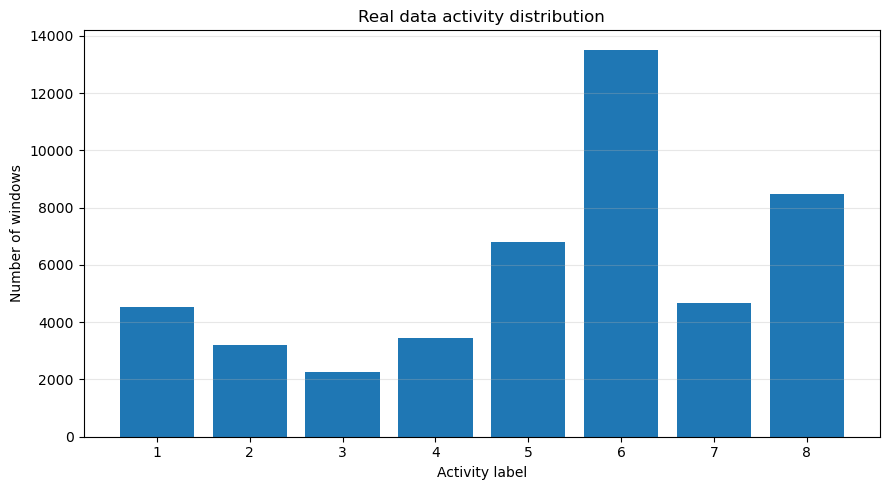

Saved: /home/iailab42/khans1/projects/figures/kovae/real_activity_distribution.png


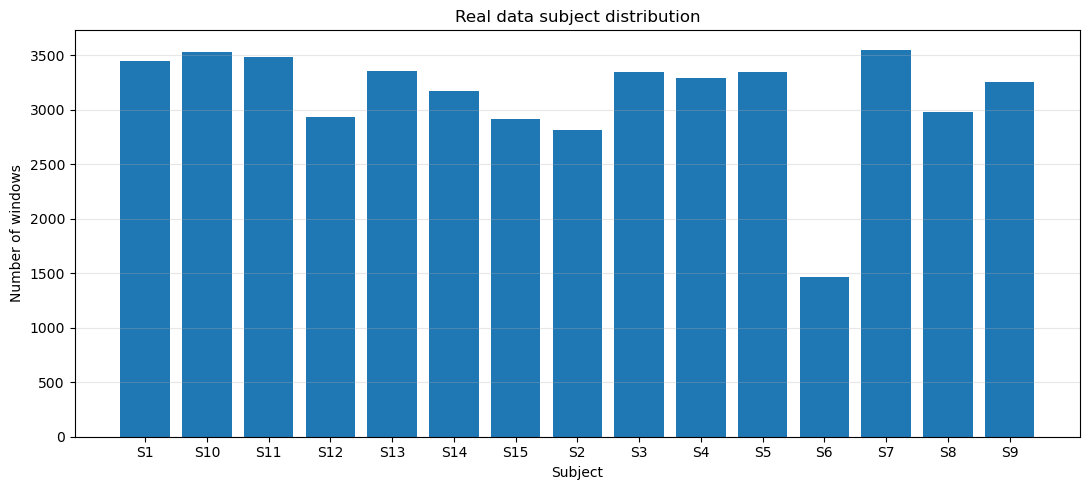

Saved: /home/iailab42/khans1/projects/figures/kovae/real_subject_distribution.png


In [31]:
activity_values, activity_counts = np.unique(y_raw, return_counts=True)
subject_values, subject_counts = np.unique(subjects_raw, return_counts=True)

activity_df = pd.DataFrame({
    "activity": activity_values.astype(str),
    "count": activity_counts,
})

subject_df = pd.DataFrame({
    "subject": subject_values.astype(str),
    "count": subject_counts,
})

print("Activity distribution:")
display(activity_df)

print("Subject distribution:")
display(subject_df)


plt.figure(figsize=(9, 5))
plt.bar(activity_df["activity"], activity_df["count"])
plt.xlabel("Activity label")
plt.ylabel("Number of windows")
plt.title("Real data activity distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

activity_plot_path = FIGURE_DIR / "real_activity_distribution.png"
plt.savefig(activity_plot_path, dpi=300)
plt.show()

print("Saved:", activity_plot_path)


plt.figure(figsize=(11, 5))
plt.bar(subject_df["subject"], subject_df["count"])
plt.xlabel("Subject")
plt.ylabel("Number of windows")
plt.title("Real data subject distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

subject_plot_path = FIGURE_DIR / "real_subject_distribution.png"
plt.savefig(subject_plot_path, dpi=300)
plt.show()

print("Saved:", subject_plot_path)

### Convert subjects and activities into IDs


In [32]:
def natural_subject_key(subject_name):
    match = re.search(r"\d+", str(subject_name))
    return int(match.group()) if match else str(subject_name)


def make_subject_mapping(subjects):
    unique_subjects = sorted(
        pd.Series(subjects).astype(str).unique().tolist(),
        key=natural_subject_key,
    )

    subject_to_id = {subject: idx for idx, subject in enumerate(unique_subjects)}
    id_to_subject = {idx: subject for subject, idx in subject_to_id.items()}

    encoded = np.array(
        [subject_to_id[str(subject)] for subject in subjects],
        dtype=np.int64,
    )

    return encoded, subject_to_id, id_to_subject


def make_activity_mapping(labels):
    unique_labels = sorted(pd.Series(labels).astype(int).unique().tolist())

    activity_to_id = {str(label): idx for idx, label in enumerate(unique_labels)}
    id_to_activity = {idx: str(label) for label, idx in activity_to_id.items()}

    encoded = np.array(
        [activity_to_id[str(int(label))] for label in labels],
        dtype=np.int64,
    )

    return encoded, activity_to_id, id_to_activity


subject_ids, subject_to_id, id_to_subject = make_subject_mapping(subjects_raw)
activity_ids, activity_to_id, id_to_activity = make_activity_mapping(y_raw)

num_subjects = len(subject_to_id)
num_activities = len(activity_to_id)

print("Subject mapping:")
print(subject_to_id)

print("\nActivity mapping:")
print(activity_to_id)

print("\nnum_subjects:", num_subjects)
print("num_activities:", num_activities)

mapping_path = RESULT_DIR / f"{cfg.model_name}_label_mappings.json"

with open(mapping_path, "w") as f:
    json.dump(
        {
            "subject_to_id": subject_to_id,
            "id_to_subject": id_to_subject,
            "activity_to_id": activity_to_id,
            "id_to_activity": id_to_activity,
            "channels": list(cfg.channels),
        },
        f,
        indent=2,
    )

print("Saved:", mapping_path)

Subject mapping:
{'S1': 0, 'S2': 1, 'S3': 2, 'S4': 3, 'S5': 4, 'S6': 5, 'S7': 6, 'S8': 7, 'S9': 8, 'S10': 9, 'S11': 10, 'S12': 11, 'S13': 12, 'S14': 13, 'S15': 14}

Activity mapping:
{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7}

num_subjects: 15
num_activities: 8
Saved: /home/iailab42/khans1/projects/results/kovae/kovae_v2_all_channels_subject_activity_label_mappings.json


### Dataset and DataLoader

x           → physiological signal window <br>
subject_id  → subject condition <br>
activity_id → activity condition <br>

KoVAE receives both signal itself and who produced it (subject) + what activity it is

In [33]:
class PPGWindowDataset(Dataset):
    def __init__(self, X, activity_ids, subject_ids):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.activity_ids = torch.tensor(activity_ids, dtype=torch.long)
        self.subject_ids = torch.tensor(subject_ids, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "x": self.X[idx],
            "activity_id": self.activity_ids[idx],
            "subject_id": self.subject_ids[idx],
        }


dataset = PPGWindowDataset(X, activity_ids, subject_ids)

n_total = len(dataset)
n_train = int(cfg.train_ratio * n_total)
n_val = int(cfg.val_ratio * n_total)
n_test = n_total - n_train - n_val

generator = torch.Generator().manual_seed(cfg.seed)

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=generator,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
)

print("Train windows:", len(train_dataset))
print("Validation windows:", len(val_dataset))
print("Test windows:", len(test_dataset))

batch = next(iter(train_loader))
print("\nOne batch:")
print("x:", batch["x"].shape)
print("subject_id:", batch["subject_id"].shape)
print("activity_id:", batch["activity_id"].shape)

Train windows: 37525
Validation windows: 4690
Test windows: 4692

One batch:
x: torch.Size([64, 512, 6])
subject_id: torch.Size([64])
activity_id: torch.Size([64])


real signal + subject/activity <br>
        ↓
encoder creates latent representation <br>
        ↓
Koopman encourages smooth latent dynamics <br>
        ↓
decoder reconstructs signal 

### KoVAE model configuration

In [34]:
@dataclass
class KoVAEModelConfig:
    input_dim: int
    latent_dim: int
    hidden_dim: int
    condition_dim: int
    subject_emb_dim: int
    activity_emb_dim: int
    global_noise_dim: int
    num_subjects: int
    num_activities: int
    num_layers: int = 1
    dropout: float = 0.0
    koopman_ridge: float = 1e-4
    alpha_koopman: float = 1.0
    beta_kl: float = 1e-2
    gamma_prior_recon: float = 0.5

### Condition encoder

S1       → subject embedding <br>
Walking  → activity embedding

combine to condition vector

In [35]:
class ConditionEncoder(nn.Module):
    def __init__(self, model_cfg):
        super().__init__()

        self.subject_emb = nn.Embedding(
            model_cfg.num_subjects,
            model_cfg.subject_emb_dim,
        )

        self.activity_emb = nn.Embedding(
            model_cfg.num_activities,
            model_cfg.activity_emb_dim,
        )

        input_dim = model_cfg.subject_emb_dim + model_cfg.activity_emb_dim

        self.project = nn.Sequential(
            nn.Linear(input_dim, model_cfg.condition_dim),
            nn.ReLU(),
            nn.Linear(model_cfg.condition_dim, model_cfg.condition_dim),
        )

    def forward(self, subject_id, activity_id):
        subject_vec = self.subject_emb(subject_id)
        activity_vec = self.activity_emb(activity_id)

        condition = torch.cat([subject_vec, activity_vec], dim=-1)

        return self.project(condition)

    def from_subject_vector(self, subject_vec, activity_id):
        activity_vec = self.activity_emb(activity_id)

        condition = torch.cat([subject_vec, activity_vec], dim=-1)

        return self.project(condition)

### Posterior encoder

[512, 6] -> latent sequence <br>

q(z | x, subject, activity) <br>

Given this real signal, <br>
what hidden latent representation explains it?

In [36]:
class PosteriorEncoder(nn.Module):
    def __init__(self, model_cfg):
        super().__init__()

        self.gru = nn.GRU(
            input_size=model_cfg.input_dim + model_cfg.condition_dim,
            hidden_size=model_cfg.hidden_dim,
            num_layers=model_cfg.num_layers,
            batch_first=True,
            dropout=model_cfg.dropout if model_cfg.num_layers > 1 else 0.0,
        )

        self.to_mu = nn.Linear(model_cfg.hidden_dim, model_cfg.latent_dim)
        self.to_logvar = nn.Linear(model_cfg.hidden_dim, model_cfg.latent_dim)

    def forward(self, x, condition):
        condition_seq = condition.unsqueeze(1).expand(-1, x.size(1), -1)

        x_conditioned = torch.cat([x, condition_seq], dim=-1)

        h, _ = self.gru(x_conditioned)

        mu = self.to_mu(h)
        logvar = self.to_logvar(h)

        return mu, logvar

### Conditional prior

Deosn't see real signal <br>
Sees :subject/activity condition
+ random noise 
produce latent sequence

global_noise_dim allows same subject/activity generate different window

In [37]:
class ConditionalPrior(nn.Module):
    def __init__(self, model_cfg):
        super().__init__()

        self.model_cfg = model_cfg

        self.gru = nn.GRU(
            input_size=model_cfg.condition_dim + model_cfg.global_noise_dim,
            hidden_size=model_cfg.hidden_dim,
            num_layers=model_cfg.num_layers,
            batch_first=True,
            dropout=model_cfg.dropout if model_cfg.num_layers > 1 else 0.0,
        )

        self.to_mu = nn.Linear(model_cfg.hidden_dim, model_cfg.latent_dim)
        self.to_logvar = nn.Linear(model_cfg.hidden_dim, model_cfg.latent_dim)

    def forward(self, condition, seq_len, global_noise=None):
        batch_size = condition.size(0)

        if global_noise is None:
            global_noise = torch.randn(
                batch_size,
                self.model_cfg.global_noise_dim,
                device=condition.device,
                dtype=condition.dtype,
            )

        condition_with_noise = torch.cat([condition, global_noise], dim=-1)
        condition_seq = condition_with_noise.unsqueeze(1).expand(-1, seq_len, -1)

        h, _ = self.gru(condition_seq)

        mu = self.to_mu(h)
        logvar = self.to_logvar(h)

        return mu, logvar

### Decoder
latent sequence <br>
+ subject/activity condition<br>
        ↓ <br>
ACC_x, ACC_y, ACC_z, BVP, EDA, TEMP

In [38]:
class Decoder(nn.Module):
    def __init__(self, model_cfg):
        super().__init__()

        self.gru = nn.GRU(
            input_size=model_cfg.latent_dim + model_cfg.condition_dim,
            hidden_size=model_cfg.hidden_dim,
            num_layers=model_cfg.num_layers,
            batch_first=True,
            dropout=model_cfg.dropout if model_cfg.num_layers > 1 else 0.0,
        )

        self.out = nn.Linear(model_cfg.hidden_dim, model_cfg.input_dim)

    def forward(self, z, condition):
        condition_seq = condition.unsqueeze(1).expand(-1, z.size(1), -1)

        z_conditioned = torch.cat([z, condition_seq], dim=-1)

        h, _ = self.gru(z_conditioned)

        return self.out(h)

### VAE and Koopman helper functions

1. Reparameterization

Lets the model sample latent variables while still training with backpropagation.

2. KL loss

Pushes the posterior and prior closer together.

3. Koopman prediction
This is the KoVAE-specific part.

It tries to learn a linear map in latent space:

z(t) → z(t+1)

In [39]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)

    eps = torch.randn_like(std)

    return mu + eps * std


def gaussian_kl(q_mu, q_logvar, p_mu, p_logvar):
    return 0.5 * (
        p_logvar
        - q_logvar
        + (torch.exp(q_logvar) + (q_mu - p_mu).pow(2)) / torch.exp(p_logvar)
        - 1.0
    )


def koopman_predict(z, ridge=1e-4):
    z0 = z[:, :-1, :]
    z1 = z[:, 1:, :]

    _, _, latent_dim = z0.shape

    eye = torch.eye(
        latent_dim,
        device=z.device,
        dtype=z.dtype,
    ).unsqueeze(0)

    xtx = torch.bmm(z0.transpose(1, 2), z0)
    xty = torch.bmm(z0.transpose(1, 2), z1)

    a_t = torch.linalg.solve(
        xtx + ridge * eye,
        xty,
    )

    z1_hat = torch.bmm(z0, a_t)

    z_hat = torch.cat([z[:, :1, :], z1_hat], dim=1)

    koopman_matrix = a_t.transpose(1, 2)

    return z_hat, koopman_matrix

### Full Conditional KoVAE

combines everything. <br>

Losses:
1. recon_loss
   Can posterior latent reconstruct real signal?

2. prior_recon_loss
   Can prior/generated latent reconstruct real signal?

3. pred_loss
   Does Koopman latent prediction work?

4. kl_loss
   Are posterior and prior close enough?

In [40]:
class ConditionalKoVAE(nn.Module):
    def __init__(self, model_cfg):
        super().__init__()

        self.cfg = model_cfg

        self.condition_encoder = ConditionEncoder(model_cfg)
        self.posterior = PosteriorEncoder(model_cfg)
        self.prior = ConditionalPrior(model_cfg)
        self.decoder = Decoder(model_cfg)

    def forward(self, x, subject_id, activity_id):
        condition = self.condition_encoder(subject_id, activity_id)

        q_mu, q_logvar = self.posterior(x, condition)
        z_q = reparameterize(q_mu, q_logvar)
        x_hat = self.decoder(z_q, condition)

        p_mu, p_logvar = self.prior(
            condition,
            seq_len=x.size(1),
        )

        z_p = reparameterize(p_mu, p_logvar)

        z_koop, koopman_matrix = koopman_predict(
            z_p,
            ridge=self.cfg.koopman_ridge,
        )

        x_prior_hat = self.decoder(z_koop, condition)

        recon_loss = F.mse_loss(x_hat, x)

        prior_recon_loss = F.mse_loss(x_prior_hat, x)

        pred_loss = F.mse_loss(
            z_koop[:, 1:, :],
            z_p[:, 1:, :],
        )

        kl_loss = gaussian_kl(
            q_mu,
            q_logvar,
            p_mu,
            p_logvar,
        ).mean()

        total_loss = (
            recon_loss
            + self.cfg.gamma_prior_recon * prior_recon_loss
            + self.cfg.alpha_koopman * pred_loss
            + self.cfg.beta_kl * kl_loss
        )

        return {
            "loss": total_loss,
            "recon_loss": recon_loss,
            "prior_recon_loss": prior_recon_loss,
            "pred_loss": pred_loss,
            "kl_loss": kl_loss,
            "x_hat": x_hat,
            "x_prior_hat": x_prior_hat,
            "z_q": z_q,
            "z_p": z_p,
            "z_koop": z_koop,
            "koopman_matrix": koopman_matrix,
        }

    @torch.no_grad()
    def reconstruct(self, x, subject_id, activity_id):
        self.eval()

        out = self.forward(
            x,
            subject_id,
            activity_id,
        )

        return out["x_hat"], out["x_prior_hat"]

    @torch.no_grad()
    def generate_from_ids(self, subject_id, activity_id, seq_len):
        self.eval()

        condition = self.condition_encoder(
            subject_id,
            activity_id,
        )

        p_mu, p_logvar = self.prior(
            condition,
            seq_len=seq_len,
        )

        z_p = reparameterize(p_mu, p_logvar)

        z_koop, koopman_matrix = koopman_predict(
            z_p,
            ridge=self.cfg.koopman_ridge,
        )

        x_gen = self.decoder(
            z_koop,
            condition,
        )

        return x_gen, koopman_matrix

    @torch.no_grad()
    def generate_from_subject_vector(self, subject_vec, activity_id, seq_len):
        self.eval()

        condition = self.condition_encoder.from_subject_vector(
            subject_vec,
            activity_id,
        )

        p_mu, p_logvar = self.prior(
            condition,
            seq_len=seq_len,
        )

        z_p = reparameterize(p_mu, p_logvar)

        z_koop, koopman_matrix = koopman_predict(
            z_p,
            ridge=self.cfg.koopman_ridge,
        )

        x_gen = self.decoder(
            z_koop,
            condition,
        )

        return x_gen, koopman_matrix

### Create model and optimizer

In [41]:
model_cfg = KoVAEModelConfig(
    input_dim=input_dim,
    latent_dim=cfg.latent_dim,
    hidden_dim=cfg.hidden_dim,
    condition_dim=cfg.condition_dim,
    subject_emb_dim=cfg.subject_emb_dim,
    activity_emb_dim=cfg.activity_emb_dim,
    global_noise_dim=cfg.global_noise_dim,
    num_subjects=num_subjects,
    num_activities=num_activities,
    num_layers=cfg.num_layers,
    dropout=cfg.dropout,
    koopman_ridge=cfg.koopman_ridge,
    alpha_koopman=cfg.alpha_koopman,
    beta_kl=cfg.beta_kl,
    gamma_prior_recon=cfg.gamma_prior_recon,
)

model = ConditionalKoVAE(model_cfg).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
)

num_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Model created successfully.")
print("Trainable parameters:", f"{num_params:,}")
print("Input dimension:", input_dim)
print("Sequence length:", seq_len)
print("Number of subjects:", num_subjects)
print("Number of activities:", num_activities)

Model created successfully.
Trainable parameters: 212,726
Input dimension: 6
Sequence length: 512
Number of subjects: 15
Number of activities: 8


### Training utility functions

In [42]:
def move_batch_to_device(batch, device):
    return {
        "x": batch["x"].to(device, non_blocking=True),
        "subject_id": batch["subject_id"].to(device, non_blocking=True),
        "activity_id": batch["activity_id"].to(device, non_blocking=True),
    }


def run_epoch(model, loader, optimizer=None, train=True):
    model.train(train)

    totals = {
        "loss": 0.0,
        "recon_loss": 0.0,
        "prior_recon_loss": 0.0,
        "pred_loss": 0.0,
        "kl_loss": 0.0,
    }

    n_batches = 0

    for batch in loader:
        batch = move_batch_to_device(batch, DEVICE)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            out = model(
                batch["x"],
                batch["subject_id"],
                batch["activity_id"],
            )

            loss = out["loss"]

            if train:
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    cfg.grad_clip_norm,
                )

                optimizer.step()

        for key in totals:
            totals[key] += float(out[key].detach().cpu())

        n_batches += 1

    metrics = {
        key: value / max(n_batches, 1)
        for key, value in totals.items()
    }

    return metrics

### Load existing model or train new model

In [43]:
def save_checkpoint(
    path,
    model,
    model_cfg,
    cfg,
    subject_to_id,
    activity_to_id,
    id_to_subject,
    id_to_activity,
    epoch=None,
    best_val_loss=None,
):
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "model_config": asdict(model_cfg),
            "experiment_config": asdict(cfg),
            "subject_to_id": subject_to_id,
            "activity_to_id": activity_to_id,
            "id_to_subject": id_to_subject,
            "id_to_activity": id_to_activity,
            "channels": list(cfg.channels),
            "epoch": epoch,
            "best_val_loss": best_val_loss,
        },
        path,
    )


def load_checkpoint(path, model, device):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    return checkpoint


if best_model_path.exists() and not cfg.force_retrain:
    print("Saved model found.")
    print("Loading model instead of training:")
    print(best_model_path)

    checkpoint = load_checkpoint(
        best_model_path,
        model,
        DEVICE,
    )

    print("Loaded checkpoint.")
    print("Best epoch:", checkpoint.get("epoch"))
    print("Best validation loss:", checkpoint.get("best_val_loss"))

else:
    print("No saved model found, or force_retrain=True.")
    print("Starting training...")

    history = []
    best_val_loss = float("inf")
    best_epoch = None

    start_time = time.time()

    for epoch in range(1, cfg.max_epochs + 1):
        train_metrics = run_epoch(
            model,
            train_loader,
            optimizer=optimizer,
            train=True,
        )

        val_metrics = run_epoch(
            model,
            val_loader,
            optimizer=None,
            train=False,
        )

        row = {
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }

        history.append(row)

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch

            save_checkpoint(
                best_model_path,
                model,
                model_cfg,
                cfg,
                subject_to_id,
                activity_to_id,
                id_to_subject,
                id_to_activity,
                epoch=epoch,
                best_val_loss=best_val_loss,
            )

        print(
            f"Epoch {epoch:03d} | "
            f"train {train_metrics['loss']:.5f} | "
            f"val {val_metrics['loss']:.5f} | "
            f"recon {val_metrics['recon_loss']:.5f} | "
            f"prior_recon {val_metrics['prior_recon_loss']:.5f} | "
            f"koopman {val_metrics['pred_loss']:.5f} | "
            f"kl {val_metrics['kl_loss']:.5f}"
        )

    save_checkpoint(
        last_model_path,
        model,
        model_cfg,
        cfg,
        subject_to_id,
        activity_to_id,
        id_to_subject,
        id_to_activity,
        epoch=cfg.max_epochs,
        best_val_loss=best_val_loss,
    )

    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False)

    elapsed_minutes = (time.time() - start_time) / 60.0

    print("\nTraining finished.")
    print("Elapsed minutes:", round(elapsed_minutes, 2))
    print("Best epoch:", best_epoch)
    print("Best validation loss:", best_val_loss)
    print("Best model saved to:", best_model_path)
    print("Training history saved to:", history_path)

    checkpoint = load_checkpoint(
        best_model_path,
        model,
        DEVICE,
    )

    print("Reloaded best model for evaluation.")

No saved model found, or force_retrain=True.
Starting training...
Epoch 001 | train 0.43112 | val 0.31119 | recon 0.01489 | prior_recon 0.53872 | koopman 0.00959 | kl 1.73497
Epoch 002 | train 0.29882 | val 0.30230 | recon 0.01138 | prior_recon 0.53774 | koopman 0.00750 | kl 1.45399
Epoch 003 | train 0.28900 | val 0.29003 | recon 0.00791 | prior_recon 0.52482 | koopman 0.00677 | kl 1.29435
Epoch 004 | train 0.28279 | val 0.28143 | recon 0.00526 | prior_recon 0.51557 | koopman 0.00610 | kl 1.22855
Epoch 005 | train 0.27804 | val 0.27736 | recon 0.00499 | prior_recon 0.51225 | koopman 0.00527 | kl 1.09744
Epoch 006 | train 0.27554 | val 0.28239 | recon 0.00575 | prior_recon 0.52260 | koopman 0.00507 | kl 1.02728
Epoch 007 | train 0.27456 | val 0.28094 | recon 0.00482 | prior_recon 0.51671 | koopman 0.00548 | kl 1.22802
Epoch 008 | train 0.27387 | val 0.27564 | recon 0.00534 | prior_recon 0.51201 | koopman 0.00455 | kl 0.97483
Epoch 009 | train 0.27297 | val 0.27398 | recon 0.00368 | prio

### Plot Training Curves
1. total_loss_curve.png <br>
2. reconstruction_and_koopman_losses.png <br>
3. kl_loss_curve.png <br>

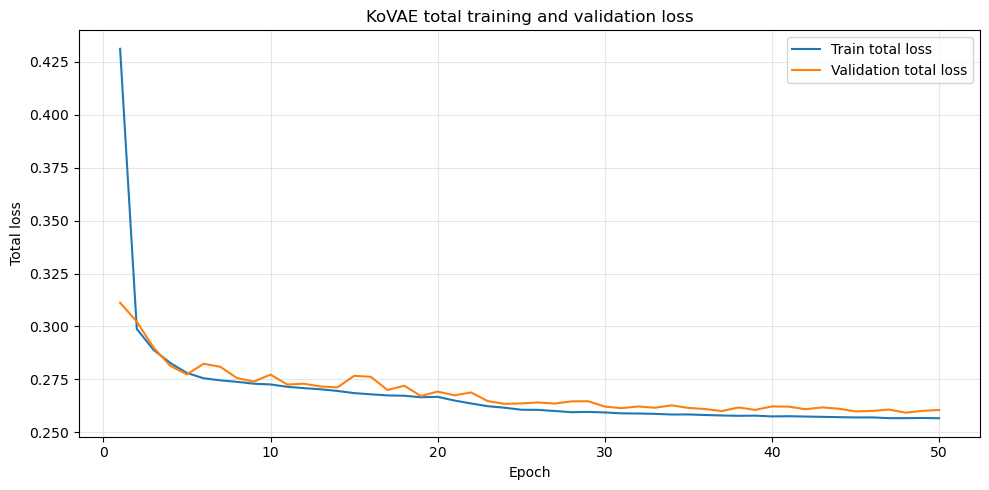

Saved: /home/iailab42/khans1/projects/figures/kovae/kovae_v2_all_channels_subject_activity_total_loss_curve.png


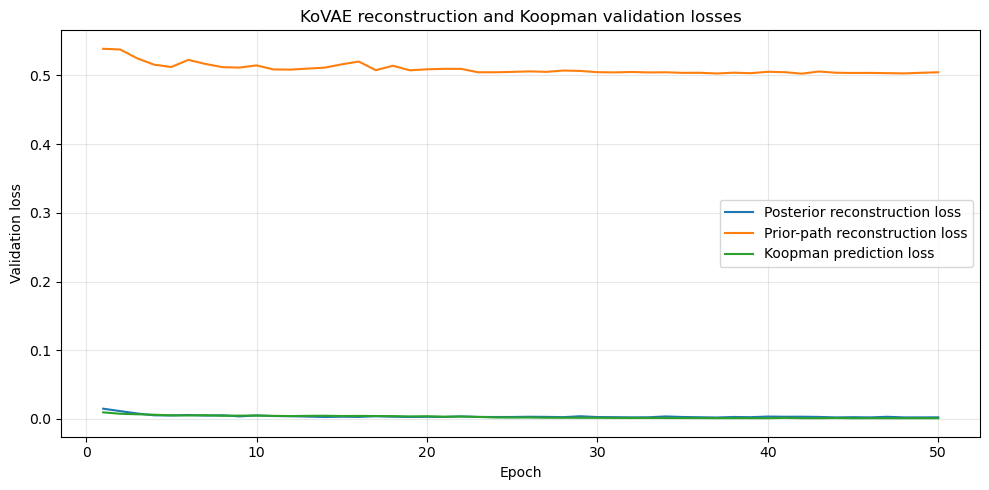

Saved: /home/iailab42/khans1/projects/figures/kovae/kovae_v2_all_channels_subject_activity_reconstruction_koopman_losses.png


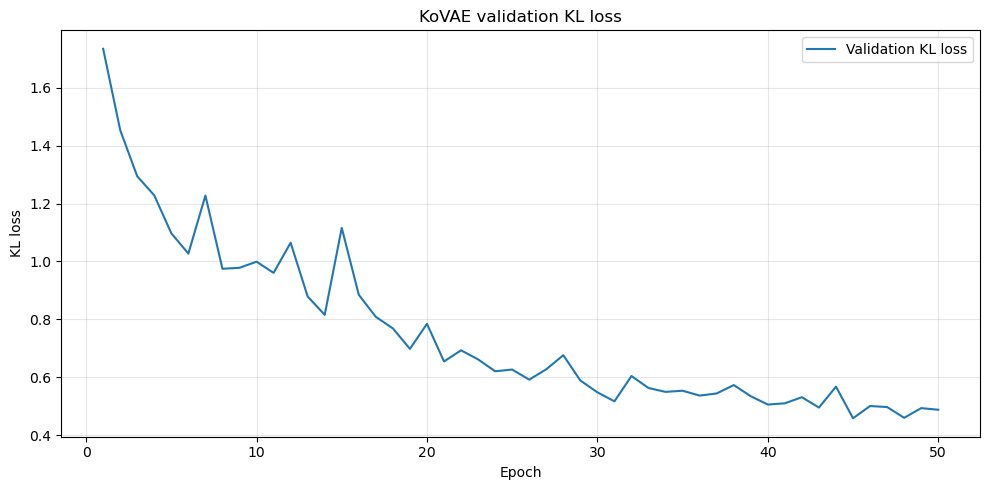

Saved: /home/iailab42/khans1/projects/figures/kovae/kovae_v2_all_channels_subject_activity_kl_loss_curve.png


In [44]:
if history_path.exists():
    history_df = pd.read_csv(history_path)

    plt.figure(figsize=(10, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train total loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation total loss")
    plt.xlabel("Epoch")
    plt.ylabel("Total loss")
    plt.title("KoVAE total training and validation loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    total_loss_path = FIGURE_DIR / f"{cfg.model_name}_total_loss_curve.png"
    plt.savefig(total_loss_path, dpi=300)
    plt.show()

    print("Saved:", total_loss_path)

    plt.figure(figsize=(10, 5))
    plt.plot(
        history_df["epoch"],
        history_df["val_recon_loss"],
        label="Posterior reconstruction loss",
    )
    plt.plot(
        history_df["epoch"],
        history_df["val_prior_recon_loss"],
        label="Prior-path reconstruction loss",
    )
    plt.plot(
        history_df["epoch"],
        history_df["val_pred_loss"],
        label="Koopman prediction loss",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Validation loss")
    plt.title("KoVAE reconstruction and Koopman validation losses")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    small_loss_path = FIGURE_DIR / f"{cfg.model_name}_reconstruction_koopman_losses.png"
    plt.savefig(small_loss_path, dpi=300)
    plt.show()

    print("Saved:", small_loss_path)

    plt.figure(figsize=(10, 5))
    plt.plot(
        history_df["epoch"],
        history_df["val_kl_loss"],
        label="Validation KL loss",
    )
    plt.xlabel("Epoch")
    plt.ylabel("KL loss")
    plt.title("KoVAE validation KL loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    kl_loss_path = FIGURE_DIR / f"{cfg.model_name}_kl_loss_curve.png"
    plt.savefig(kl_loss_path, dpi=300)
    plt.show()

    print("Saved:", kl_loss_path)

else:
    print("No training history found. This is okay if you loaded a model trained elsewhere.")

### Test metrics and reconstruction plots
real signal <br>
posterior reconstruction <br>
prior-path reconstruction <br>

Test metrics:
{
  "loss": 0.2529025599360466,
  "recon_loss": 0.0022098429900644398,
  "prior_recon_loss": 0.49031323436144236,
  "pred_loss": 0.0009941255093262706,
  "kl_loss": 0.4541973427340791
}
Saved: /home/iailab42/khans1/projects/results/kovae/kovae_v2_all_channels_subject_activity_test_metrics.json


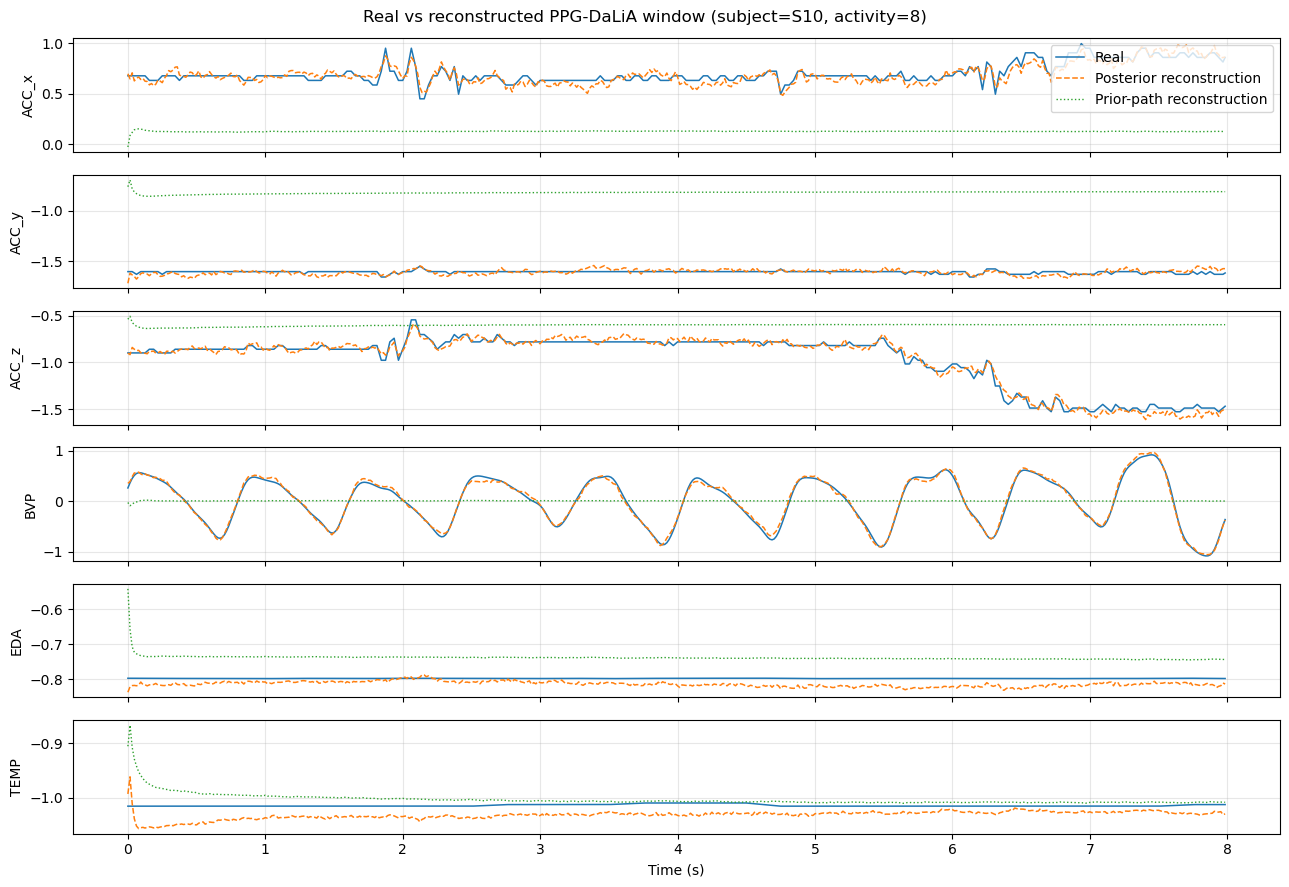

Saved: /home/iailab42/khans1/projects/figures/kovae/kovae_v2_all_channels_subject_activity_real_vs_reconstructed_example_0.png


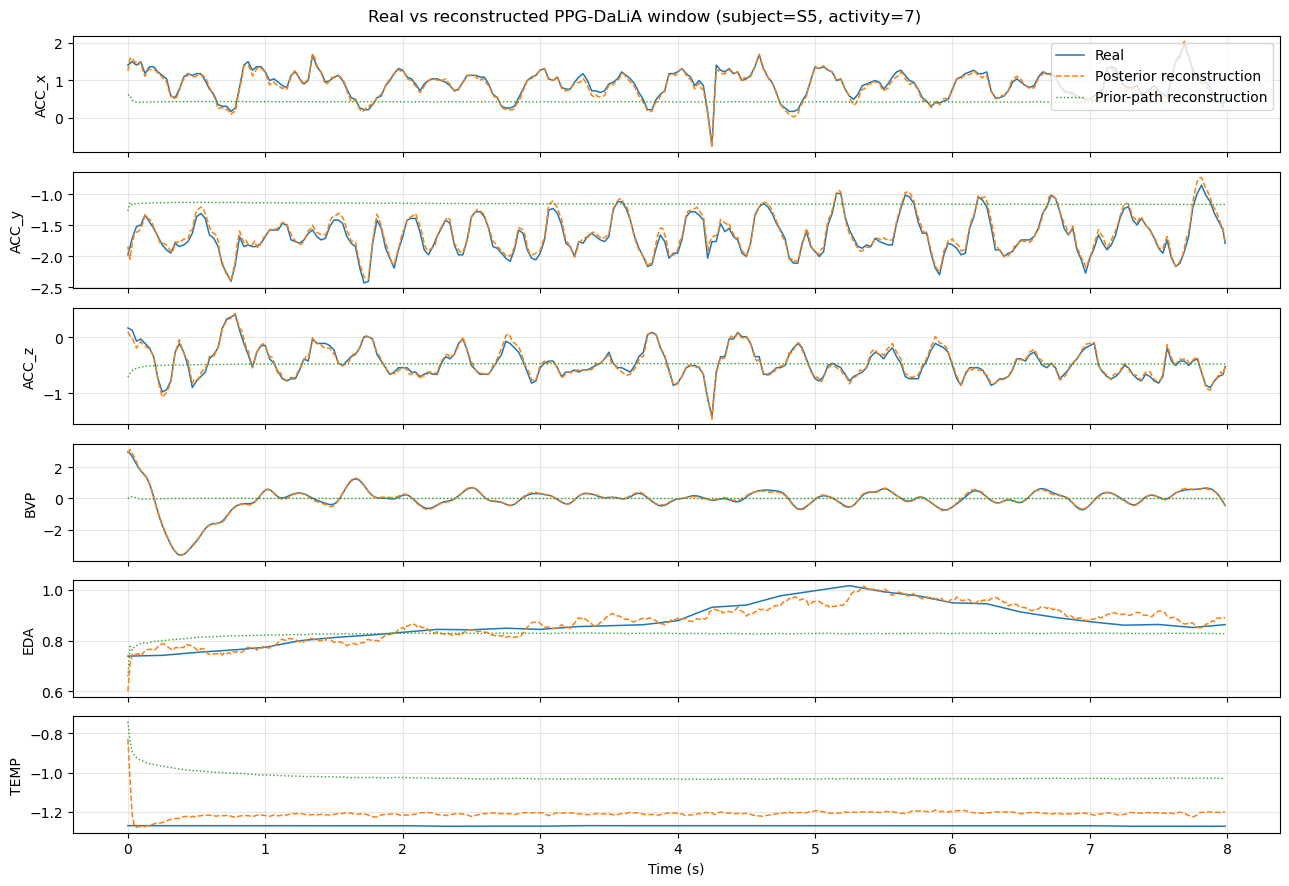

Saved: /home/iailab42/khans1/projects/figures/kovae/kovae_v2_all_channels_subject_activity_real_vs_reconstructed_example_1.png


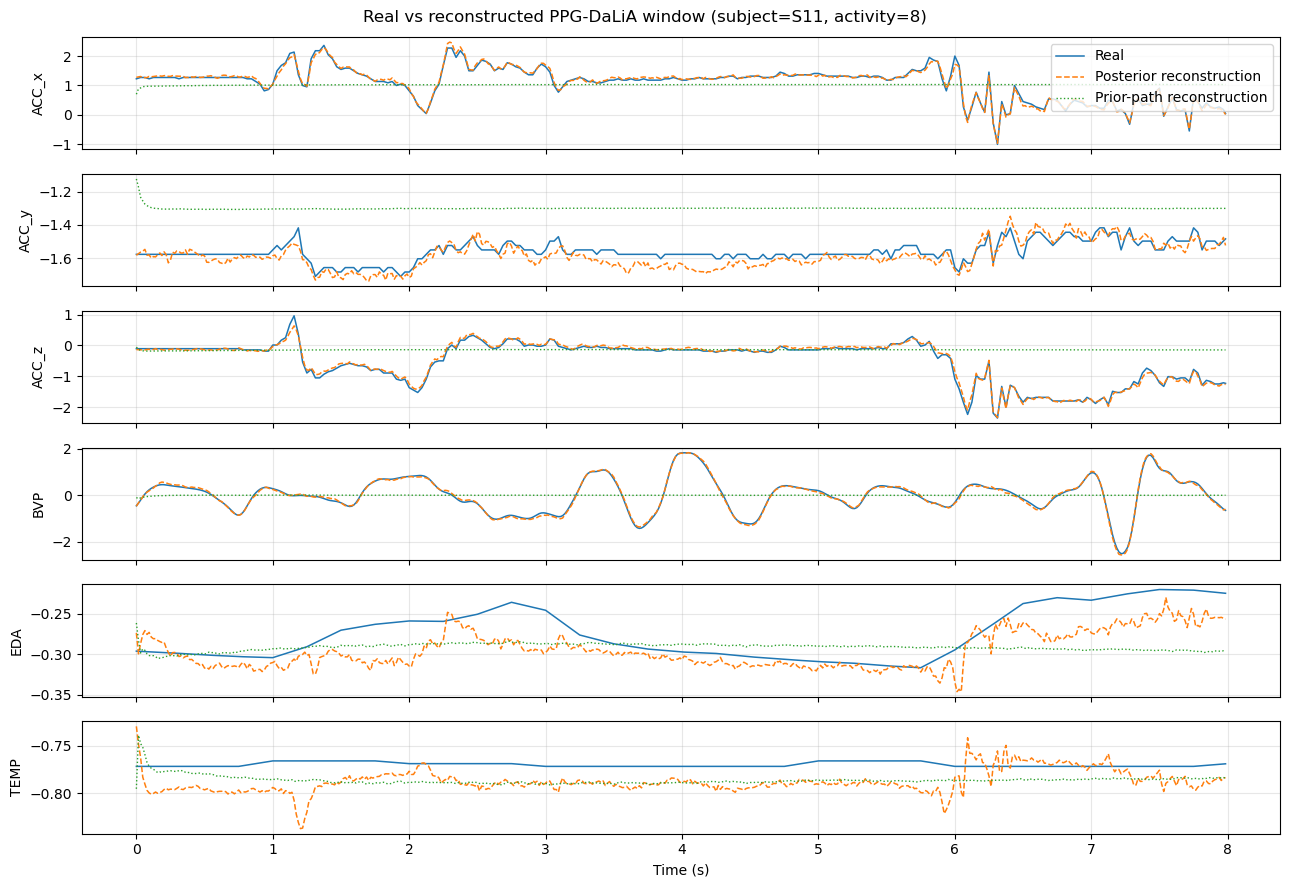

Saved: /home/iailab42/khans1/projects/figures/kovae/kovae_v2_all_channels_subject_activity_real_vs_reconstructed_example_2.png


In [45]:
test_metrics = run_epoch(
    model,
    test_loader,
    optimizer=None,
    train=False,
)

test_metrics_path = RESULT_DIR / f"{cfg.model_name}_test_metrics.json"

with open(test_metrics_path, "w") as f:
    json.dump(test_metrics, f, indent=2)

print("Test metrics:")
print(json.dumps(test_metrics, indent=2))
print("Saved:", test_metrics_path)


batch = next(iter(test_loader))
batch = move_batch_to_device(batch, DEVICE)

model.eval()

with torch.no_grad():
    x_hat, x_prior_hat = model.reconstruct(
        batch["x"],
        batch["subject_id"],
        batch["activity_id"],
    )

x_real = batch["x"].detach().cpu().numpy()
x_recon = x_hat.detach().cpu().numpy()
x_prior_recon = x_prior_hat.detach().cpu().numpy()

time_axis = np.arange(seq_len) / float(cfg.sampling_rate_hz)

n_examples = min(3, x_real.shape[0])

for i in range(n_examples):
    fig, axes = plt.subplots(
        input_dim,
        1,
        figsize=(13, 9),
        sharex=True,
    )

    for c in range(input_dim):
        axes[c].plot(
            time_axis,
            x_real[i, :, c],
            label="Real",
            linewidth=1.1,
        )

        axes[c].plot(
            time_axis,
            x_recon[i, :, c],
            label="Posterior reconstruction",
            linewidth=1.1,
            linestyle="--",
        )

        axes[c].plot(
            time_axis,
            x_prior_recon[i, :, c],
            label="Prior-path reconstruction",
            linewidth=1.0,
            linestyle=":",
        )

        axes[c].set_ylabel(cfg.channels[c])
        axes[c].grid(True, alpha=0.3)

    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel("Time (s)")

    subject_name = id_to_subject[int(batch["subject_id"][i].detach().cpu())]
    activity_name = id_to_activity[int(batch["activity_id"][i].detach().cpu())]

    fig.suptitle(
        f"Real vs reconstructed PPG-DaLiA window "
        f"(subject={subject_name}, activity={activity_name})"
    )

    plt.tight_layout()

    recon_path = FIGURE_DIR / f"{cfg.model_name}_real_vs_reconstructed_example_{i}.png"
    plt.savefig(recon_path, dpi=300)
    plt.show()

    print("Saved:", recon_path)

### Pure Prior Generation

In [46]:
@torch.no_grad()
def sample_synthetic_subject_vectors(
    model,
    num_synthetic_subjects,
    noise_scale=0.4,
):
    real_subject_emb = model.condition_encoder.subject_emb.weight.detach()

    subject_mean = real_subject_emb.mean(dim=0, keepdim=True)
    subject_std = real_subject_emb.std(dim=0, keepdim=True).clamp_min(1e-4)

    synthetic_vectors = subject_mean + noise_scale * torch.randn(
        num_synthetic_subjects,
        real_subject_emb.size(1),
        device=real_subject_emb.device,
    ) * subject_std

    return synthetic_vectors


@torch.no_grad()
def generate_synthetic_prior_mode(
    model,
    num_synthetic_subjects,
    windows_per_activity,
    seq_len,
    subject_noise_scale=0.4,
):
    model.eval()

    synthetic_subject_vectors = sample_synthetic_subject_vectors(
        model=model,
        num_synthetic_subjects=num_synthetic_subjects,
        noise_scale=subject_noise_scale,
    )

    synthetic_X = []
    synthetic_y_original = []
    synthetic_y_internal = []
    synthetic_subject_names = []

    for syn_idx in range(num_synthetic_subjects):
        subject_vec = synthetic_subject_vectors[syn_idx:syn_idx + 1]

        for activity_id in range(num_activities):
            activity_tensor = torch.tensor(
                [activity_id],
                dtype=torch.long,
                device=DEVICE,
            )

            original_activity_label = int(id_to_activity[activity_id])

            for _ in range(windows_per_activity):
                x_syn, _ = model.generate_from_subject_vector(
                    subject_vec=subject_vec,
                    activity_id=activity_tensor,
                    seq_len=seq_len,
                )

                synthetic_X.append(x_syn.detach().cpu().numpy()[0])
                synthetic_y_original.append(original_activity_label)
                synthetic_y_internal.append(activity_id)
                synthetic_subject_names.append(f"SYN_{syn_idx + 1:03d}")

    synthetic_X = np.stack(synthetic_X).astype(np.float32)
    synthetic_y_original = np.array(synthetic_y_original, dtype=np.int64)
    synthetic_y_internal = np.array(synthetic_y_internal, dtype=np.int64)
    synthetic_subject_names = np.array(synthetic_subject_names)

    return (
        synthetic_X,
        synthetic_y_original,
        synthetic_y_internal,
        synthetic_subject_names,
    )


prior_X, prior_y, prior_y_internal, prior_subjects = generate_synthetic_prior_mode(
    model=model,
    num_synthetic_subjects=cfg.num_synthetic_subjects,
    windows_per_activity=cfg.windows_per_activity,
    seq_len=seq_len,
    subject_noise_scale=cfg.synthetic_subject_noise_scale,
)

print("Prior-mode synthetic X:", prior_X.shape)
print("Prior-mode synthetic y:", prior_y.shape)
print("Prior-mode synthetic subjects:", prior_subjects.shape)
print("Labels:", np.unique(prior_y, return_counts=True))
print("Subjects:", np.unique(prior_subjects, return_counts=True))

Prior-mode synthetic X: (8000, 512, 6)
Prior-mode synthetic y: (8000,)
Prior-mode synthetic subjects: (8000,)
Labels: (array([1, 2, 3, 4, 5, 6, 7, 8]), array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))
Subjects: (array(['SYN_001', 'SYN_002', 'SYN_003', 'SYN_004', 'SYN_005', 'SYN_006',
       'SYN_007', 'SYN_008', 'SYN_009', 'SYN_010'], dtype='<U7'), array([800, 800, 800, 800, 800, 800, 800, 800, 800, 800]))


In [48]:
prior_dir = SYNTHETIC_DIR / "prior"
prior_dir.mkdir(parents=True, exist_ok=True)

np.save(prior_dir / "all_X_synthetic.npy", prior_X)
np.save(prior_dir / "all_y_synthetic.npy", prior_y)
np.save(prior_dir / "all_y_internal_synthetic.npy", prior_y_internal)
np.save(prior_dir / "all_subject_synthetic.npy", prior_subjects)

prior_metadata = pd.DataFrame({
    "synthetic_window_id": np.arange(len(prior_y)),
    "synthetic_subject": prior_subjects,
    "activity_label": prior_y,
    "activity_internal_id": prior_y_internal,
    "generation_method": "pure_prior",
    "start_sample_64hz": 0,
    "end_sample_64hz": seq_len,
    "start_time_sec": 0.0,
    "end_time_sec": seq_len / float(cfg.sampling_rate_hz),
})

prior_metadata.to_csv(prior_dir / "all_metadata_synthetic.csv", index=False)

print("Saved pure prior synthetic data to:", prior_dir)

Saved pure prior synthetic data to: /home/iailab42/khans1/projects/data/synthetic/prior


### Plot for Prior

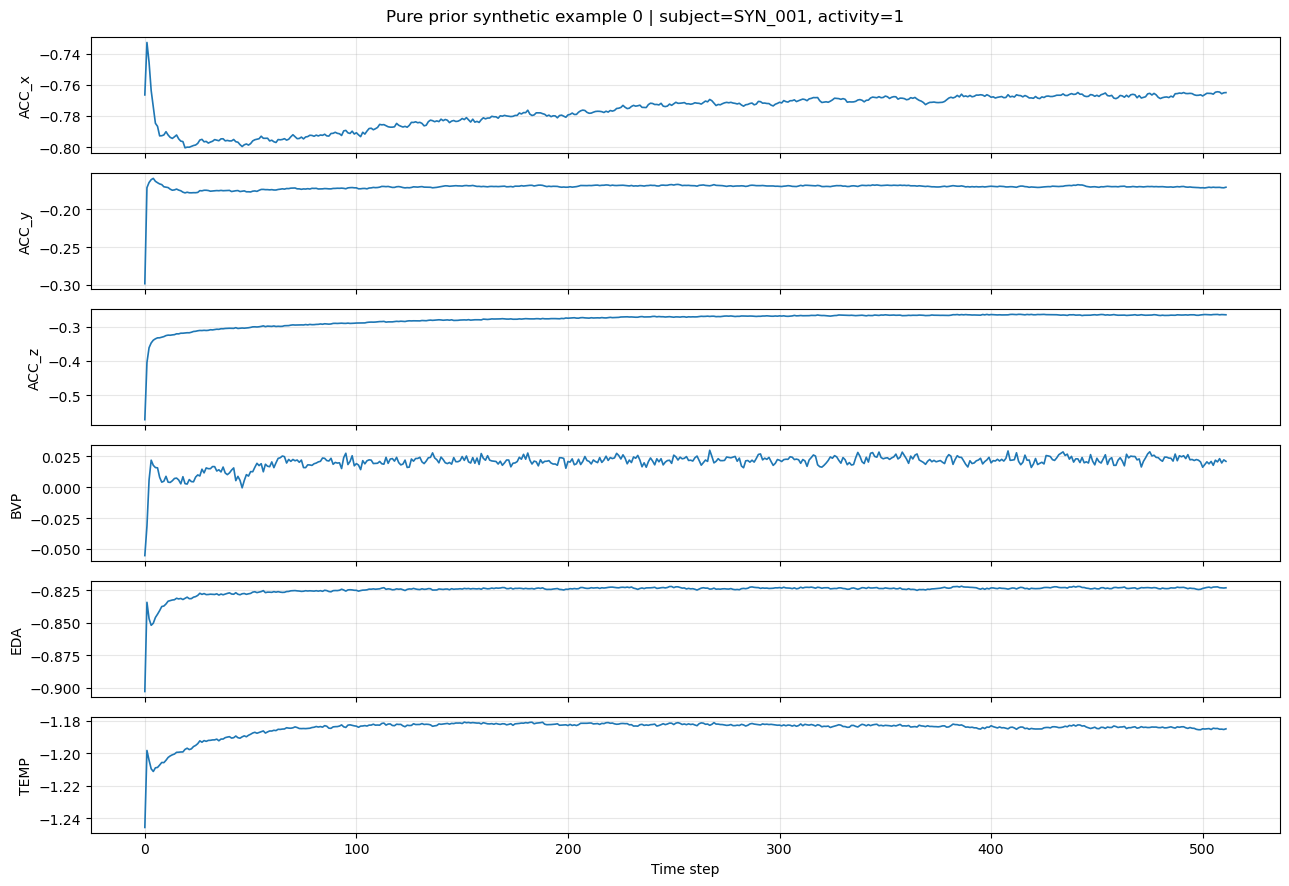

Saved: /home/iailab42/khans1/projects/figures/kovae/synthetic_prior/pure_prior_synthetic_example_0.png


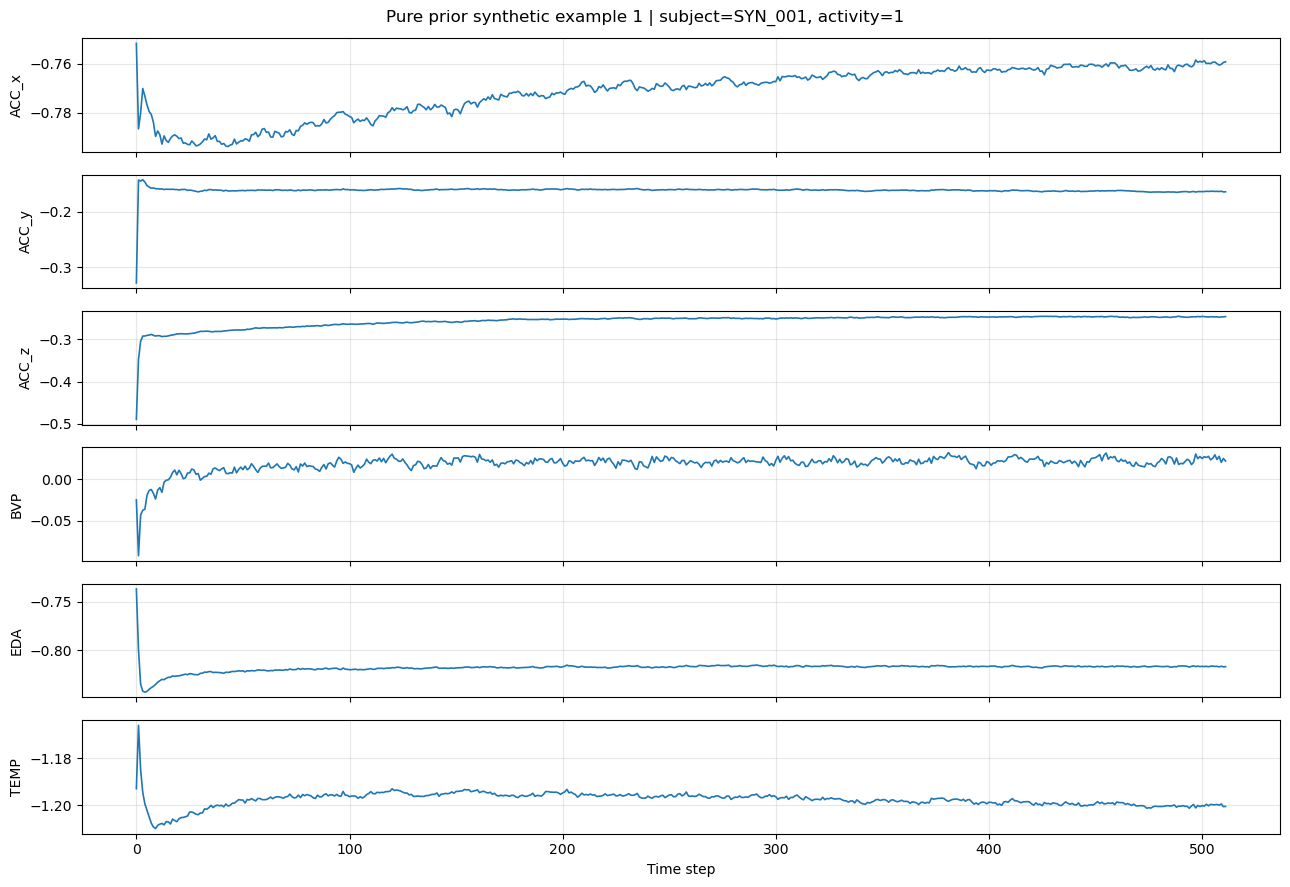

Saved: /home/iailab42/khans1/projects/figures/kovae/synthetic_prior/pure_prior_synthetic_example_1.png


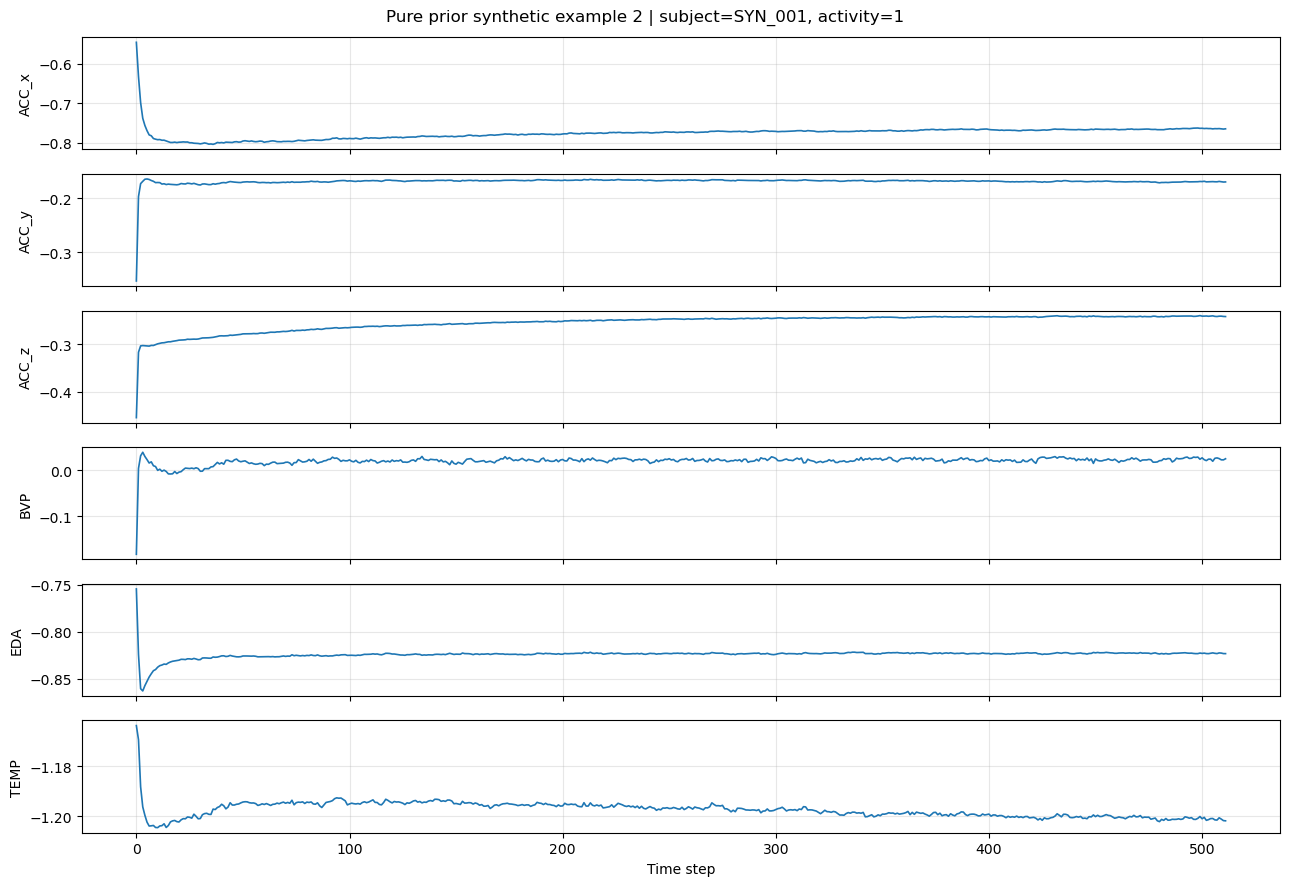

Saved: /home/iailab42/khans1/projects/figures/kovae/synthetic_prior/pure_prior_synthetic_example_2.png


In [49]:
prior_fig_dir = FIGURE_DIR / "synthetic_prior"
prior_fig_dir.mkdir(parents=True, exist_ok=True)

for i in range(min(3, len(prior_X))):
    fig, axes = plt.subplots(
        input_dim,
        1,
        figsize=(13, 9),
        sharex=True,
    )

    for c in range(input_dim):
        axes[c].plot(prior_X[i, :, c], linewidth=1.2)
        axes[c].set_ylabel(cfg.channels[c])
        axes[c].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time step")

    fig.suptitle(
        f"Pure prior synthetic example {i} | "
        f"subject={prior_subjects[i]}, activity={prior_y[i]}"
    )

    plt.tight_layout()

    out_path = prior_fig_dir / f"pure_prior_synthetic_example_{i}.png"
    plt.savefig(out_path, dpi=300)
    plt.show()

    print("Saved:", out_path)

### Posterior Mode
Collect posterior latent bank

In [50]:
@torch.no_grad()
def collect_real_latents_by_activity(
    model,
    loader,
    max_batches=None,
):
    model.eval()

    latents_by_activity = {}

    batch_count = 0

    for batch in loader:
        batch = move_batch_to_device(batch, DEVICE)

        condition = model.condition_encoder(
            batch["subject_id"],
            batch["activity_id"],
        )

        q_mu, q_logvar = model.posterior(
            batch["x"],
            condition,
        )

        for i in range(q_mu.size(0)):
            activity_id = int(batch["activity_id"][i].detach().cpu())

            if activity_id not in latents_by_activity:
                latents_by_activity[activity_id] = []

            latents_by_activity[activity_id].append(
                q_mu[i].detach().cpu()
            )

        batch_count += 1

        if max_batches is not None and batch_count >= max_batches:
            break

    for activity_id in latents_by_activity:
        latents_by_activity[activity_id] = torch.stack(
            latents_by_activity[activity_id],
            dim=0,
        )

    return latents_by_activity


real_latents_by_activity = collect_real_latents_by_activity(
    model=model,
    loader=train_loader,
    max_batches=None,
)

for activity_id, z_bank in real_latents_by_activity.items():
    print(
        "Activity internal ID:",
        activity_id,
        "| original label:",
        id_to_activity[activity_id],
        "| latent bank shape:",
        z_bank.shape,
    )

Activity internal ID: 4 | original label: 5 | latent bank shape: torch.Size([5441, 512, 16])
Activity internal ID: 6 | original label: 7 | latent bank shape: torch.Size([3708, 512, 16])
Activity internal ID: 7 | original label: 8 | latent bank shape: torch.Size([6811, 512, 16])
Activity internal ID: 5 | original label: 6 | latent bank shape: torch.Size([10811, 512, 16])
Activity internal ID: 3 | original label: 4 | latent bank shape: torch.Size([2758, 512, 16])
Activity internal ID: 1 | original label: 2 | latent bank shape: torch.Size([2549, 512, 16])
Activity internal ID: 0 | original label: 1 | latent bank shape: torch.Size([3634, 512, 16])
Activity internal ID: 2 | original label: 3 | latent bank shape: torch.Size([1813, 512, 16])


### Posterior Bank Generation
real latent trajectory <br>
 (+) small noise <br>
 (+) synthetic subject condition <br>
↓ <br> 
decoder <br>
↓ <br>
synthetic signal

In [51]:
@torch.no_grad()
def generate_synthetic_posterior_bank_mode(
    model,
    latent_bank_by_activity,
    num_synthetic_subjects,
    windows_per_activity,
    latent_noise_scale=0.03,
    subject_noise_scale=0.4,
):
    model.eval()

    real_subject_emb = model.condition_encoder.subject_emb.weight.detach()

    subject_mean = real_subject_emb.mean(dim=0, keepdim=True)
    subject_std = real_subject_emb.std(dim=0, keepdim=True).clamp_min(1e-4)

    synthetic_X = []
    synthetic_y_original = []
    synthetic_y_internal = []
    synthetic_subject_names = []

    for syn_idx in range(num_synthetic_subjects):
        subject_vec = subject_mean + subject_noise_scale * torch.randn(
            1,
            real_subject_emb.size(1),
            device=DEVICE,
        ) * subject_std

        for activity_id in range(num_activities):
            if activity_id not in latent_bank_by_activity:
                continue

            z_bank = latent_bank_by_activity[activity_id]
            n_bank = z_bank.size(0)

            activity_tensor = torch.tensor(
                [activity_id],
                dtype=torch.long,
                device=DEVICE,
            )

            original_activity_label = int(id_to_activity[activity_id])

            condition = model.condition_encoder.from_subject_vector(
                subject_vec,
                activity_tensor,
            )

            for _ in range(windows_per_activity):
                rand_idx = torch.randint(
                    low=0,
                    high=n_bank,
                    size=(1,),
                ).item()

                z_seed = z_bank[rand_idx].unsqueeze(0).to(DEVICE)

                z_seed = z_seed + latent_noise_scale * torch.randn_like(z_seed)

                x_syn = model.decoder(
                    z_seed,
                    condition,
                )

                synthetic_X.append(x_syn.detach().cpu().numpy()[0])
                synthetic_y_original.append(original_activity_label)
                synthetic_y_internal.append(activity_id)
                synthetic_subject_names.append(f"SYN_{syn_idx + 1:03d}")

    synthetic_X = np.stack(synthetic_X).astype(np.float32)
    synthetic_y_original = np.array(synthetic_y_original, dtype=np.int64)
    synthetic_y_internal = np.array(synthetic_y_internal, dtype=np.int64)
    synthetic_subject_names = np.array(synthetic_subject_names)

    return (
        synthetic_X,
        synthetic_y_original,
        synthetic_y_internal,
        synthetic_subject_names,
    )


posterior_X, posterior_y, posterior_y_internal, posterior_subjects = generate_synthetic_posterior_bank_mode(
    model=model,
    latent_bank_by_activity=real_latents_by_activity,
    num_synthetic_subjects=cfg.num_synthetic_subjects,
    windows_per_activity=cfg.windows_per_activity,
    latent_noise_scale=cfg.posterior_latent_noise_scale,
    subject_noise_scale=cfg.synthetic_subject_noise_scale,
)

print("Posterior-bank synthetic X:", posterior_X.shape)
print("Posterior-bank synthetic y:", posterior_y.shape)
print("Posterior-bank synthetic subjects:", posterior_subjects.shape)
print("Labels:", np.unique(posterior_y, return_counts=True))
print("Subjects:", np.unique(posterior_subjects, return_counts=True))

Posterior-bank synthetic X: (8000, 512, 6)
Posterior-bank synthetic y: (8000,)
Posterior-bank synthetic subjects: (8000,)
Labels: (array([1, 2, 3, 4, 5, 6, 7, 8]), array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))
Subjects: (array(['SYN_001', 'SYN_002', 'SYN_003', 'SYN_004', 'SYN_005', 'SYN_006',
       'SYN_007', 'SYN_008', 'SYN_009', 'SYN_010'], dtype='<U7'), array([800, 800, 800, 800, 800, 800, 800, 800, 800, 800]))


In [52]:
posterior_dir = SYNTHETIC_DIR / "posterior_bank"
posterior_dir.mkdir(parents=True, exist_ok=True)

np.save(posterior_dir / "all_X_synthetic.npy", posterior_X)
np.save(posterior_dir / "all_y_synthetic.npy", posterior_y)
np.save(posterior_dir / "all_y_internal_synthetic.npy", posterior_y_internal)
np.save(posterior_dir / "all_subject_synthetic.npy", posterior_subjects)

posterior_metadata = pd.DataFrame({
    "synthetic_window_id": np.arange(len(posterior_y)),
    "synthetic_subject": posterior_subjects,
    "activity_label": posterior_y,
    "activity_internal_id": posterior_y_internal,
    "generation_method": "posterior_latent_bank",
    "start_sample_64hz": 0,
    "end_sample_64hz": seq_len,
    "start_time_sec": 0.0,
    "end_time_sec": seq_len / float(cfg.sampling_rate_hz),
})

posterior_metadata.to_csv(
    posterior_dir / "all_metadata_synthetic.csv",
    index=False,
)

print("Saved posterior-bank synthetic data to:", posterior_dir)

Saved posterior-bank synthetic data to: /home/iailab42/khans1/projects/data/synthetic/posterior_bank


### Plot for posterior


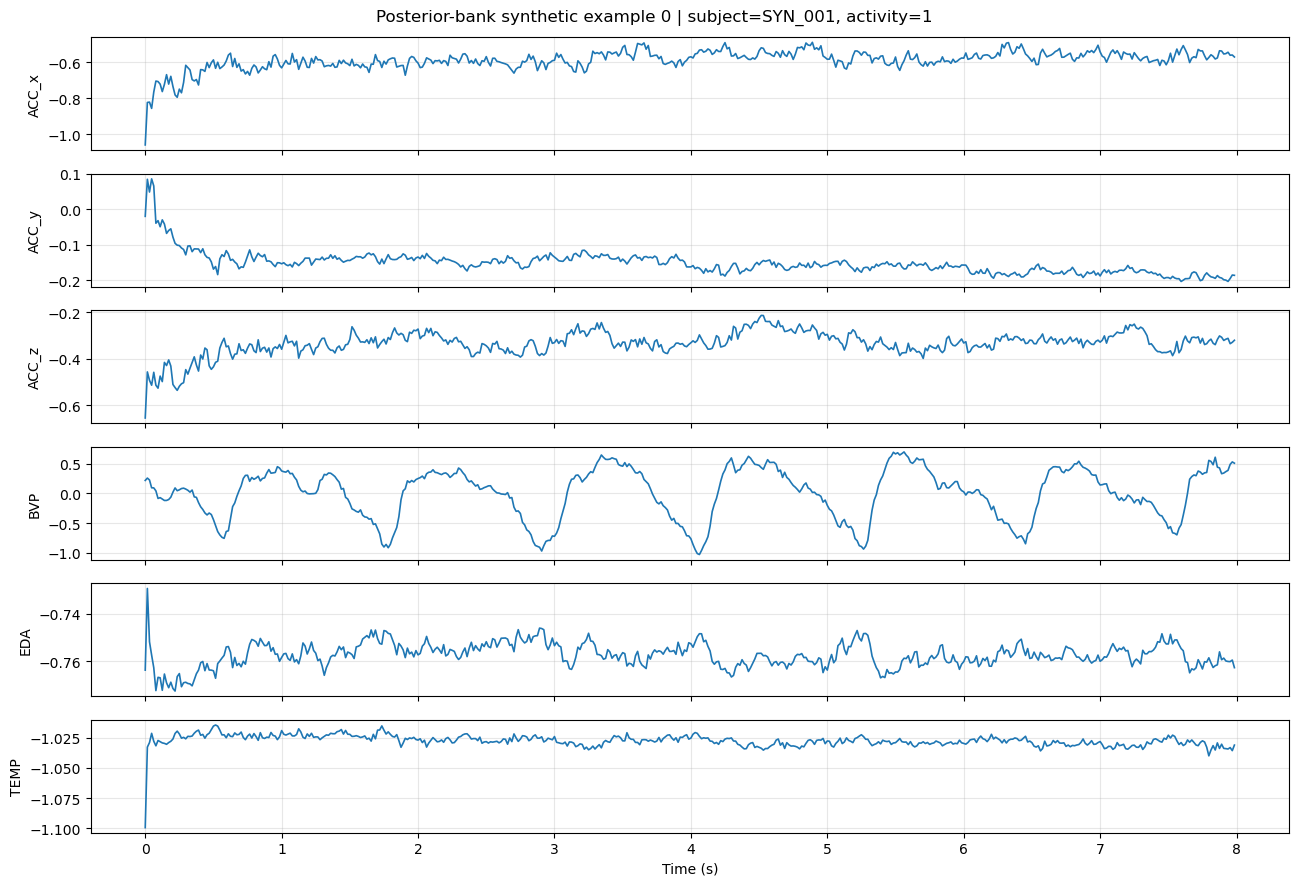

Saved: /home/iailab42/khans1/projects/figures/kovae/synthetic_posterior_bank/posterior_bank_synthetic_example_0.png


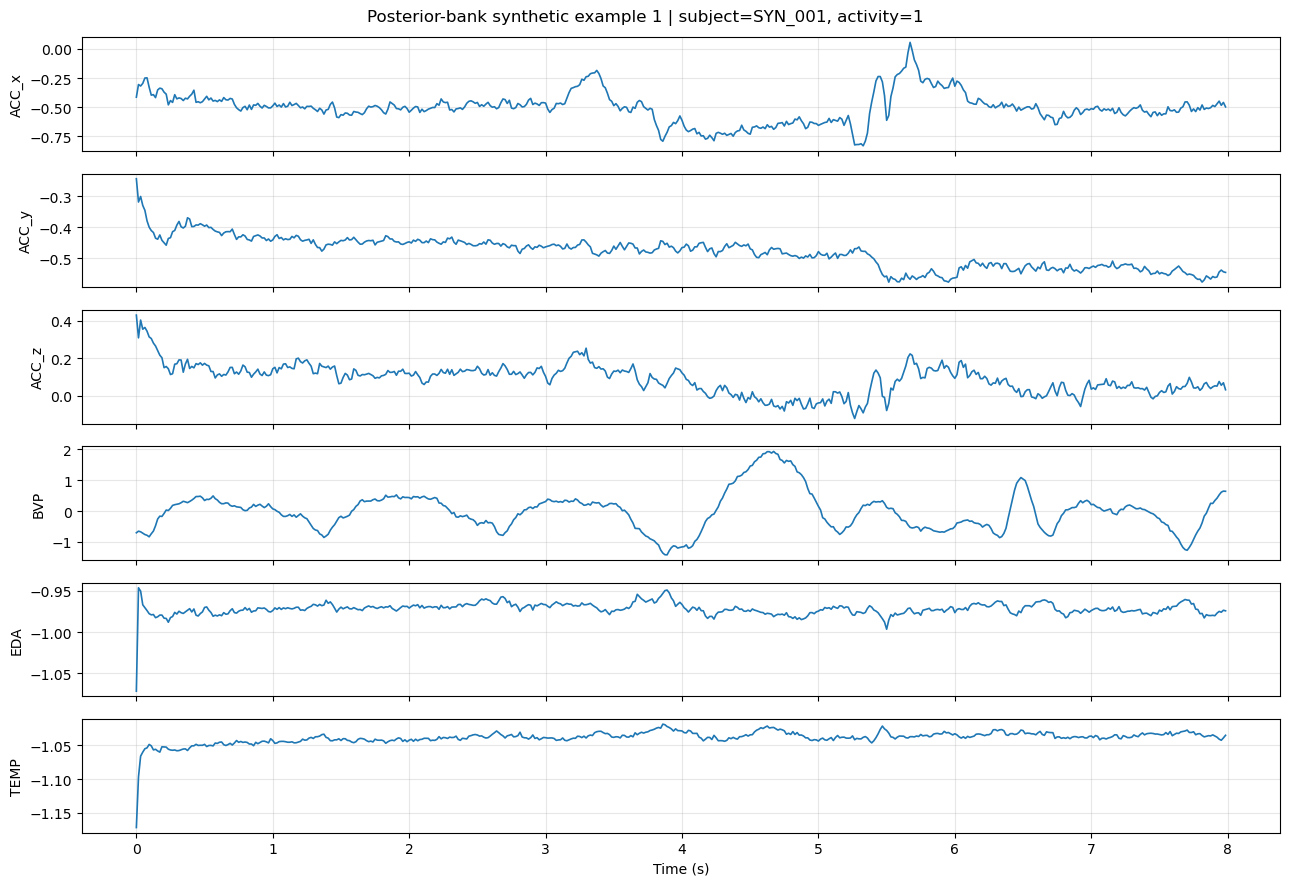

Saved: /home/iailab42/khans1/projects/figures/kovae/synthetic_posterior_bank/posterior_bank_synthetic_example_1.png


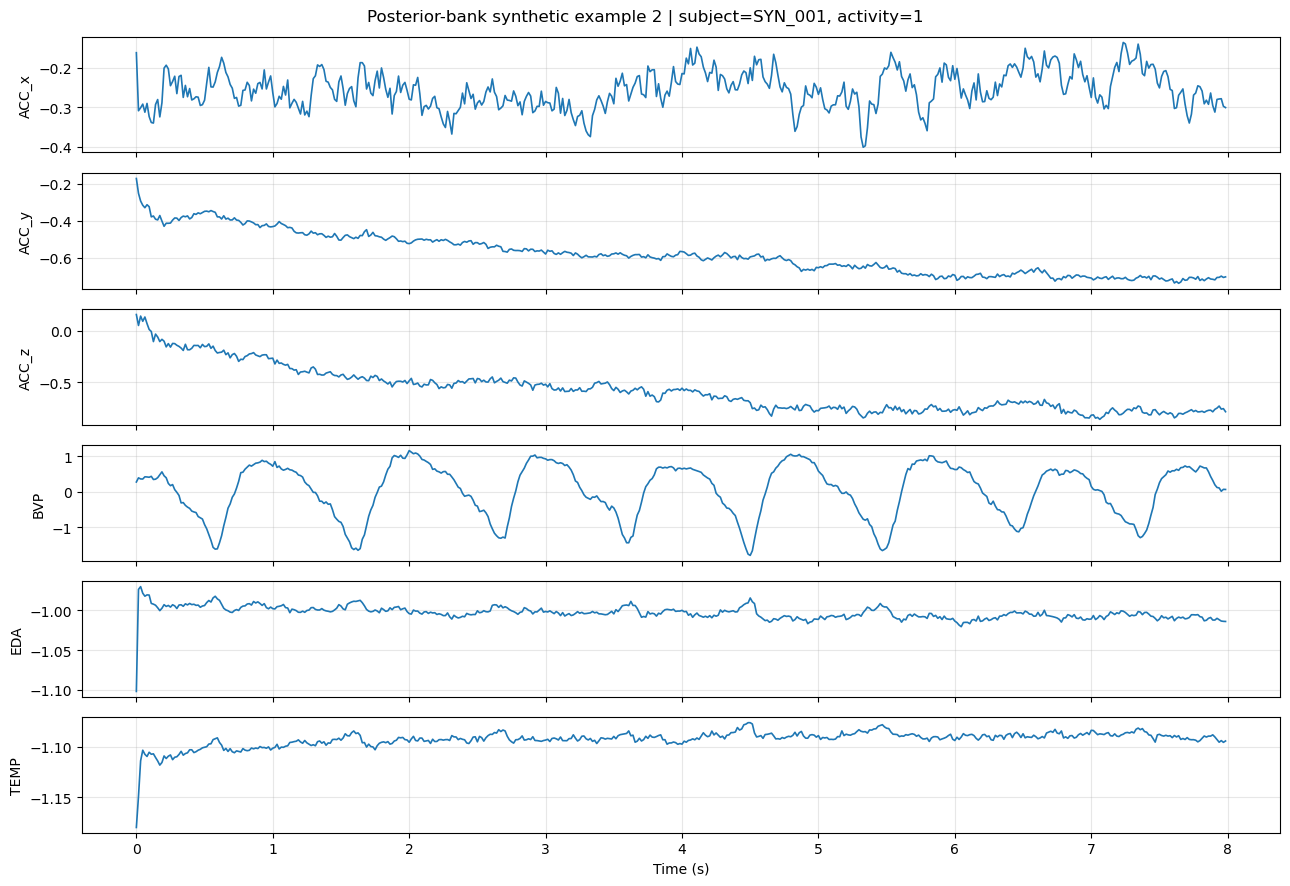

Saved: /home/iailab42/khans1/projects/figures/kovae/synthetic_posterior_bank/posterior_bank_synthetic_example_2.png


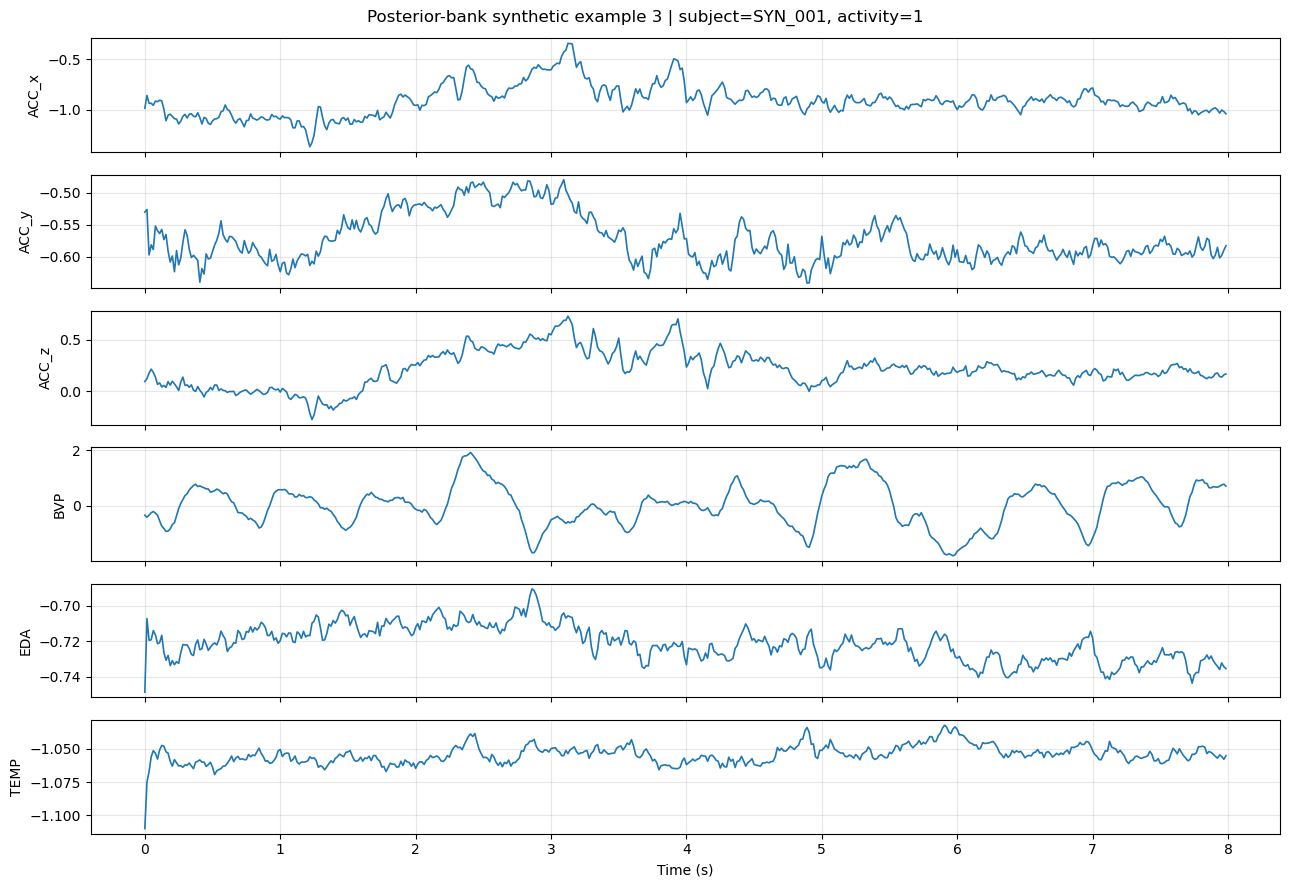

Saved: /home/iailab42/khans1/projects/figures/kovae/synthetic_posterior_bank/posterior_bank_synthetic_example_3.png


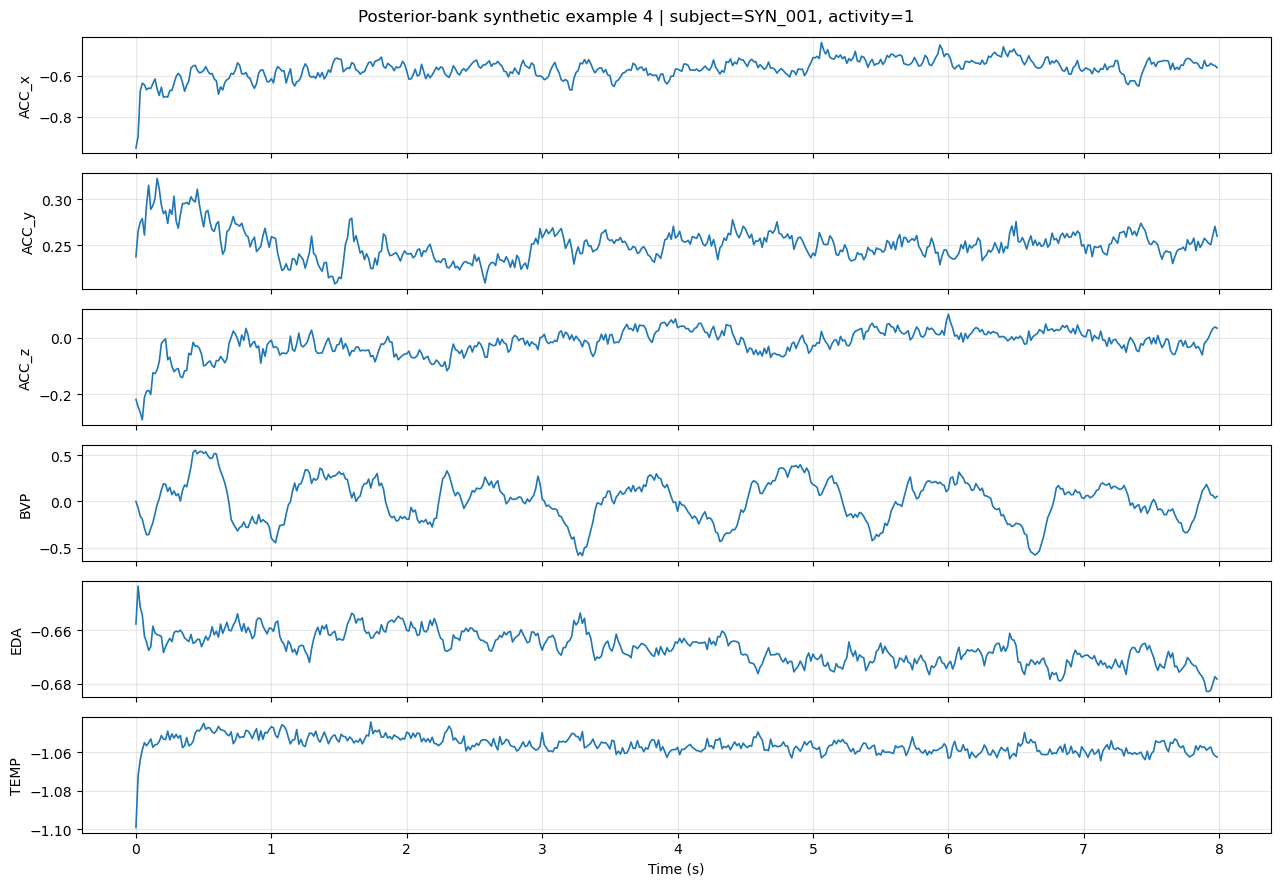

Saved: /home/iailab42/khans1/projects/figures/kovae/synthetic_posterior_bank/posterior_bank_synthetic_example_4.png


In [53]:
posterior_fig_dir = FIGURE_DIR / "synthetic_posterior_bank"
posterior_fig_dir.mkdir(parents=True, exist_ok=True)

time_axis = np.arange(seq_len) / float(cfg.sampling_rate_hz)

for i in range(min(5, len(posterior_X))):
    fig, axes = plt.subplots(
        input_dim,
        1,
        figsize=(13, 9),
        sharex=True,
    )

    for c in range(input_dim):
        axes[c].plot(time_axis, posterior_X[i, :, c], linewidth=1.2)
        axes[c].set_ylabel(cfg.channels[c])
        axes[c].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time (s)")

    fig.suptitle(
        f"Posterior-bank synthetic example {i} | "
        f"subject={posterior_subjects[i]}, activity={posterior_y[i]}"
    )

    plt.tight_layout()

    out_path = posterior_fig_dir / f"posterior_bank_synthetic_example_{i}.png"
    plt.savefig(out_path, dpi=300)
    plt.show()

    print("Saved:", out_path)

### Plot for same synthetic subject accross different activities


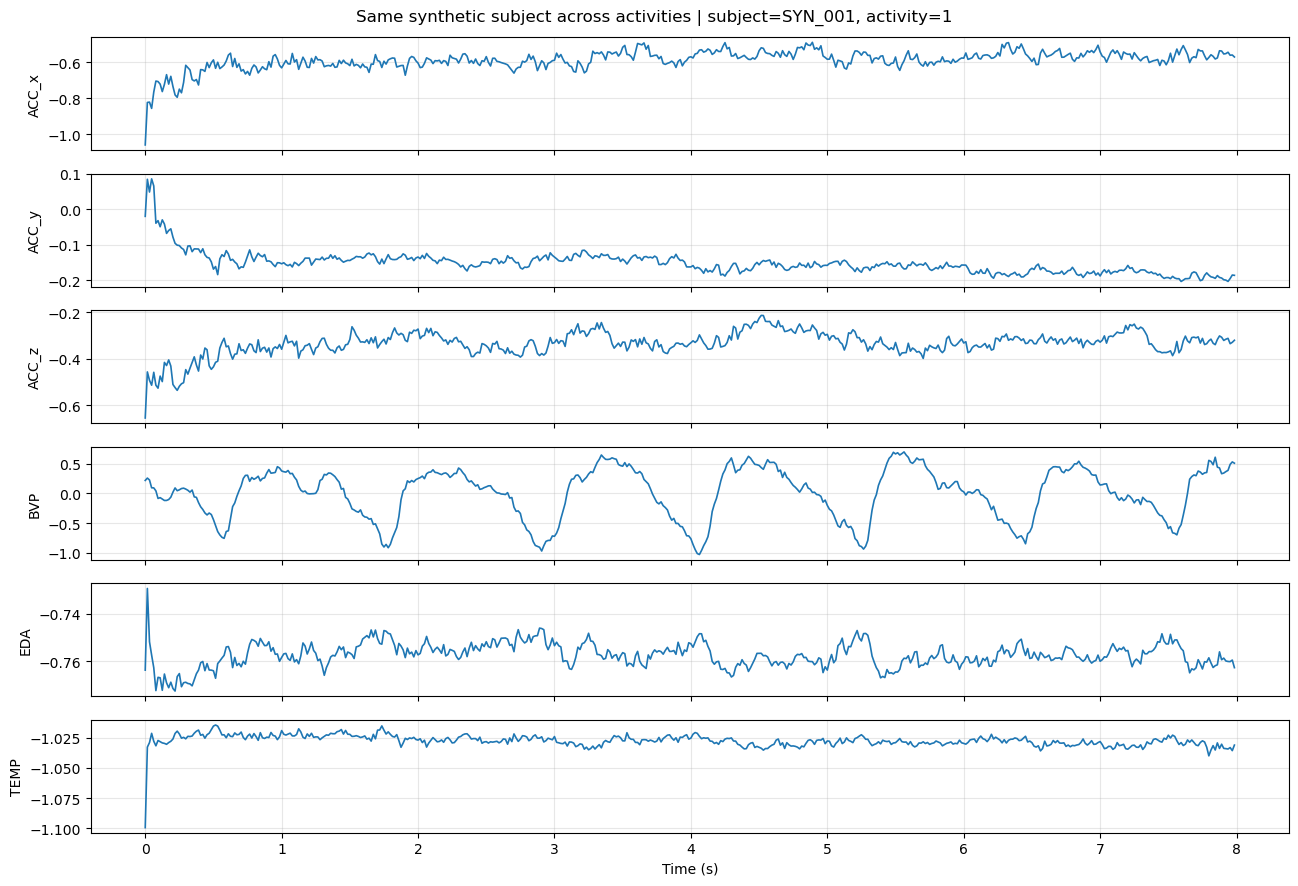

Saved: /home/iailab42/khans1/projects/figures/kovae/synthetic_posterior_bank/same_synthetic_subject_SYN_001_activity_1.png


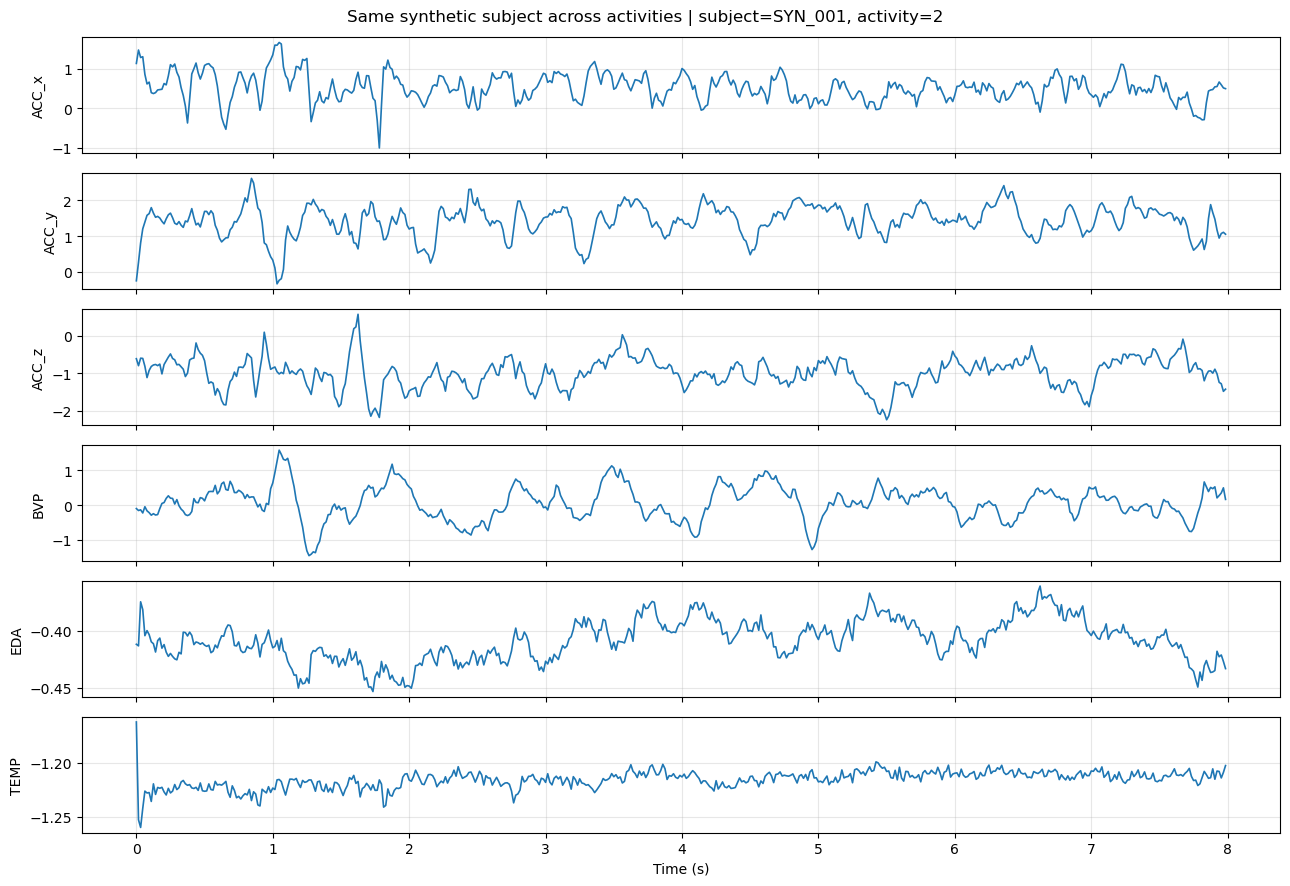

Saved: /home/iailab42/khans1/projects/figures/kovae/synthetic_posterior_bank/same_synthetic_subject_SYN_001_activity_2.png


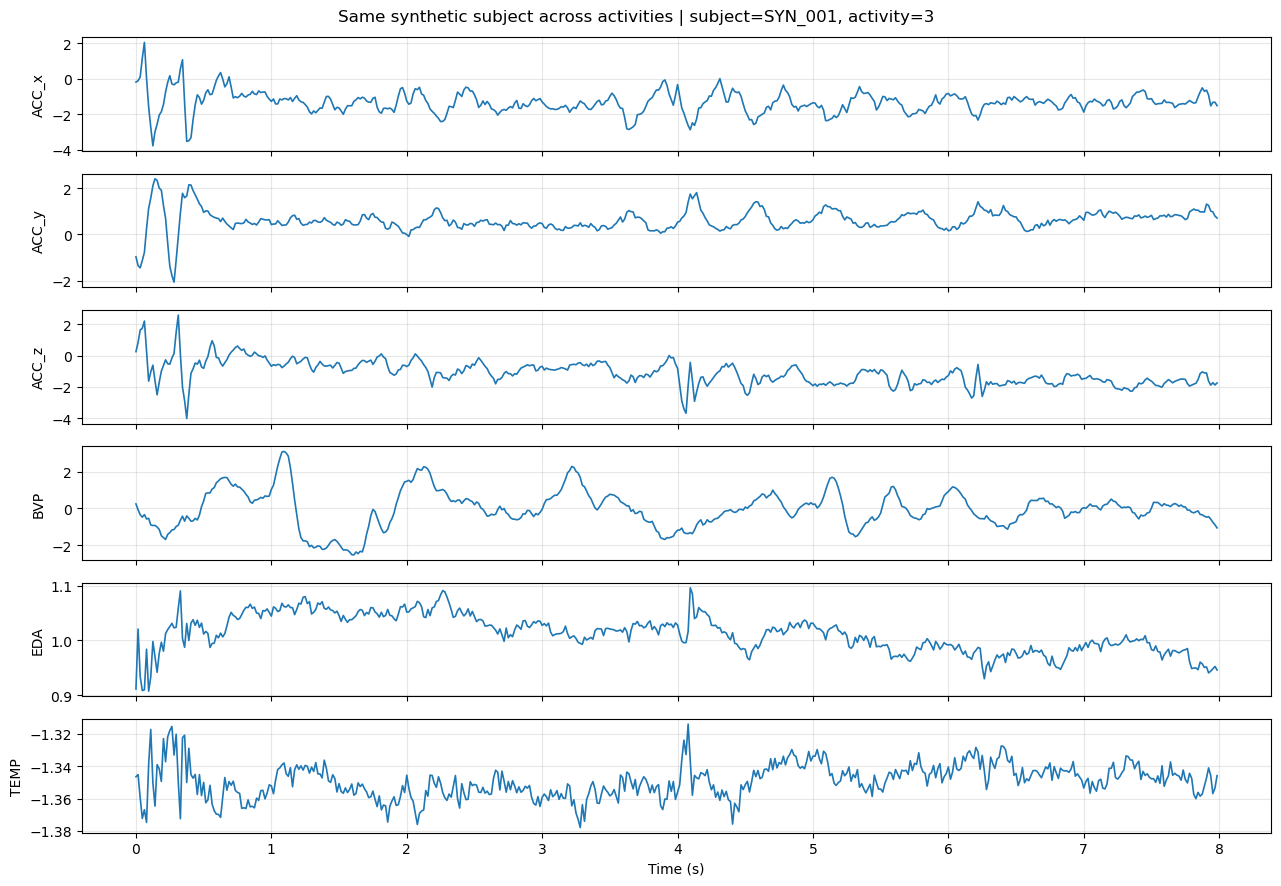

Saved: /home/iailab42/khans1/projects/figures/kovae/synthetic_posterior_bank/same_synthetic_subject_SYN_001_activity_3.png


In [54]:
same_subject_name = "SYN_001"
selected_activities = sorted(np.unique(posterior_y))[:3]

for activity_label in selected_activities:
    matching_indices = np.where(
        (posterior_subjects == same_subject_name)
        & (posterior_y == activity_label)
    )[0]

    if len(matching_indices) == 0:
        continue

    idx = matching_indices[0]
    x_syn = posterior_X[idx]

    fig, axes = plt.subplots(
        input_dim,
        1,
        figsize=(13, 9),
        sharex=True,
    )

    for c in range(input_dim):
        axes[c].plot(time_axis, x_syn[:, c], linewidth=1.2)
        axes[c].set_ylabel(cfg.channels[c])
        axes[c].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time (s)")

    fig.suptitle(
        f"Same synthetic subject across activities | "
        f"subject={same_subject_name}, activity={activity_label}"
    )

    plt.tight_layout()

    out_path = posterior_fig_dir / (
        f"same_synthetic_subject_{same_subject_name}_activity_{activity_label}.png"
    )

    plt.savefig(out_path, dpi=300)
    plt.show()

    print("Saved:", out_path)

In [ ]:
np.save(SYNTHETIC_DIR / "all_X_synthetic.npy", posterior_X)
np.save(SYNTHETIC_DIR / "all_y_synthetic.npy", posterior_y)
np.save(SYNTHETIC_DIR / "all_y_internal_synthetic.npy", posterior_y_internal)
np.save(SYNTHETIC_DIR / "all_subject_synthetic.npy", posterior_subjects)

posterior_metadata.to_csv(
    SYNTHETIC_DIR / "all_metadata_synthetic.csv",
    index=False,
)

print("Saved default synthetic files:")
print(SYNTHETIC_DIR / "all_X_synthetic.npy")
print(SYNTHETIC_DIR / "all_y_synthetic.npy")
print(SYNTHETIC_DIR / "all_subject_synthetic.npy")
print(SYNTHETIC_DIR / "all_metadata_synthetic.csv")

Saved default teammate-compatible synthetic files:
/home/iailab42/khans1/projects/data/synthetic/all_X_synthetic.npy
/home/iailab42/khans1/projects/data/synthetic/all_y_synthetic.npy
/home/iailab42/khans1/projects/data/synthetic/all_subject_synthetic.npy
/home/iailab42/khans1/projects/data/synthetic/all_metadata_synthetic.csv
